In my previous post, I looked at the simplest of state-space models, the local level/trend model, and ran the Kalman filter + smoother on it. 

In this post, I want to explore the full multivariate extension of the local trend model - the linear state space model.
Like before, these notes are based on Chapter 11 of Tsay's *Analysis of Financial Time Series (2005)*.

# Linear State-Space Models

Recall that the local trend model is given by 
$$
\mu_{t+1} = \mu_t + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)
$$
$$
y_t = \mu_t + e_t, \quad e_t \sim N(0, \sigma^2_e)
$$


Now what if instead of just one state and one observation equation, we were tracking multiple at once, so our state and observations became vectors? Our model would take the form: 

$$s_{t+1} = d_t + T_t s_t + R_t \eta_t, \quad \eta_t \sim N(0, Q_t) \tag{11.24}$$

$$y_t = c_t + Z_t s_t + e_t, \quad e_t \sim N(0, H_t)\tag{11.25}$$

- $s_t$ (m-dim) = hidden states
- $y_t$ (k-dim) = observations

- $T_t$ (m x m) = **Transition Matrix**:
    - controls how each hidden state evolves at each time step
    - T = 1 in local trend model gave us random walk

- $Z_t$ (k x k) = **Observation/Loadings Matrix**:
    - maps each hidden state to observations
    - in local trend model, Z = 1 meant we observed the state directly, plus measurement noise
    - in general model with multiple states and observations, $Z_t$ tells us how each state contributes to each observation

- $R_t$ (m x n) = **Noise Routing Matrix**:

    - routes the n-dimensional state noise $\eta_t$ into the m-dimensional state
    - usually just a subset of columns of the identity matrix, selecting which states actually receive shocks

- $d_t$ (m-dim) and $c_t$ (k-dim) = **Deterministic Offsets**:
    - allow for known deterministic components--trends, seasonal dummies, regressors
    - in local trend model they were 0, but in richer models they carry important structure

- $Q_t$ (n x n) = state noise covariance
- $H_t$ (k x k) = measurement noise covariance
 

where: 

- $m$ = number of states we're tracking
- $k$ = number of observation series we observe at each time step
- $n$ = dimension of state noise vector $\eta_t$; how many independent shocks hit the state


$$
\underbrace{\begin{bmatrix} s_{1,t+1} \\ \vdots \\ s_{m,t+1} \end{bmatrix}}_{m\times 1}
= \underbrace{\begin{bmatrix} d_{1,t} \\ \vdots \\ d_{m,t} \end{bmatrix}}_{m\times 1}
+ \underbrace{\begin{bmatrix} T_{11,t} & \cdots & T_{1m,t} \\ \vdots & \ddots & \vdots \\ T_{m1,t} & \cdots & T_{mm,t} \end{bmatrix}}_{m\times m}
\underbrace{\begin{bmatrix} s_{1,t} \\ \vdots \\ s_{m,t} \end{bmatrix}}_{m\times 1}
+ \underbrace{\begin{bmatrix} R_{11,t} & \cdots & R_{1n,t} \\ \vdots & \ddots & \vdots \\ R_{m1,t} & \cdots & R_{mn,t} \end{bmatrix}}_{m\times n}
\underbrace{\begin{bmatrix} \eta_{1,t} \\ \vdots \\ \eta_{n,t} \end{bmatrix}}_{n\times 1}
$$


$$
\underbrace{\begin{bmatrix} y_{1,t} \\ \vdots \\ y_{k,t} \end{bmatrix}}_{k\times 1}
= \underbrace{\begin{bmatrix} c_{1,t} \\ \vdots \\ c_{k,t} \end{bmatrix}}_{k\times 1}
+ \underbrace{\begin{bmatrix} Z_{11,t} & \cdots & Z_{1m,t} \\ \vdots & \ddots & \vdots \\ Z_{k1,t} & \cdots & Z_{km,t} \end{bmatrix}}_{k\times m}
\underbrace{\begin{bmatrix} s_{1,t} \\ \vdots \\ s_{m,t} \end{bmatrix}}_{m\times 1}
+ \underbrace{\begin{bmatrix} e_{1,t} \\ \vdots \\ e_{k,t} \end{bmatrix}}_{k\times 1}
$$

We can write these together in **compact form**:

$$
\begin{bmatrix} s_{1,t+1} \\ y_t \end{bmatrix} 
= \delta_t + \Phi_ts_t + \mu_t 
$$
where

$$ 
\delta_t = \begin{bmatrix} d_t \\ c_t \end{bmatrix}, 
\Phi_t = \begin{bmatrix} T_t \\ Z_t \end{bmatrix}, 
\mu_t = \begin{bmatrix} R_t\eta_t \\ \epsilon_t \end{bmatrix}, 
\Omega_t = cov(\mu_t) = \begin{bmatrix} R_tQ_tR'_t & 0\\ 0 & H_t \end{bmatrix}
$$

# Transformation into State-Space Form

In this section we'll look at how many well-known econometric and time series models can be rewritten in the general state-space form. 

## 1. CAPM with Time-Varying Coefficients

Standard CAPM can be expressed as
$$r_t = \alpha + \beta r_{m,t} + e_t$$

where 

- $r_t$ = excess asset returns (returns - risk free rate)
- $r_{m,t}$ = excess return of the market portfolio
- $\alpha$ = alpha: return not explained by market exposure. Positive alpha means that asset outperforms what its market risk would predict
- $\beta$ = beta: sensitivity to market movements
- $e_t$ = idiosyncratic noise

The problem with standard CAPM is that it assumes $\alpha$ and $\beta$ are fixed constants over time.
Empirically this is often false: a company's market sensitivity can change as its business evolves or during market crises, and alpha can appear or disappear as market conditions change.

Thus, a time-varying CAPM is motivated. 

CAPM with time-varying coefficients is expressed as 

$$r_t = \alpha_t + \beta_t r_{m,t} + e_t, \tag{observation}$$

$$\alpha_{t+1} = \alpha_{t} + \eta_{t} \tag{state}$$

$$\beta_{t+1} = \beta_{t} + \epsilon_{t} \tag{state}$$

where $\alpha$ and $\beta$ are now hidden states that evolve as random walks over time.

### Rewriting in state-space form

First, our hidden state vector: 

$$
s_t = \begin{bmatrix} \alpha_{t} \\ \beta_{t} \end{bmatrix}
$$


So our State Equation is

$$ 
\underbrace{\begin{bmatrix} \alpha_{t+1} \\ \beta_{t+1} \end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} 1 & 0 \\  0 & 1 \end{bmatrix}}_{T_t} 
\underbrace{\begin{bmatrix} \alpha_{t} \\ \beta_{t} \end{bmatrix}}_{s_t} + 
\underbrace{\begin{bmatrix} \eta_{t} \\ \epsilon_{t} \end{bmatrix}}_{s_t}
$$

Here

- $Q_t = \begin{bmatrix} \sigma^2_\eta & 0 \\  0 & \sigma^2_\epsilon \end{bmatrix}$
- $d_t = 0$  no deterministic drift
- $T_t = I^2$ each parameter follows its own random walk
- $R_t = I^2$ both states receive shocks directly

and our Observation Equation is 

$$ 
\underbrace{r_t}_{y_t} = \underbrace{\begin{bmatrix} 1 & r_{m,t} \end{bmatrix}}_{Z_t}
\underbrace{\begin{bmatrix} \alpha_t \\ \beta_t \end{bmatrix}}_{s_t} + 
\underbrace{e_t}_{e_t} 
$$

Here 

- $H_t =  \sigma^2_\epsilon$

- $c_t = 0$  no deterministic drift
- $Z_t = \begin{bmatrix} 1 \ r_{m,t} \end{bmatrix}$ time varying because $r_{m,t}$ changes with $t$; in local trend $Z = 1$

So in compact form, we have

$$
\begin{bmatrix} \alpha_{t+1} \\ \beta_{t+1} \\ r_{t+1} \end{bmatrix} = 
\underbrace{\begin{bmatrix} 0 \\ 0 \\ 0\end{bmatrix}}_{\delta_t} + 
\underbrace{\begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & r_{m,t}\end{bmatrix}}_{\Phi_t}
\begin{bmatrix} \alpha_{t} \\ \beta_{t} \\ r_t \end{bmatrix} + 
\underbrace{\begin{bmatrix} \eta_t \\ \epsilon_t \\ e_t \end{bmatrix}}_{\mu_t}
$$

$$ 
\Omega_t = \operatorname{cov}(\mu_t) = \begin{bmatrix} \sigma^2_\eta & 0 & 0 \\ 0 & \sigma^2_\epsilon & 0 \\ 0 & 0 & \sigma^2_{e} \end{bmatrix}
$$

## 2. ARMA/ARIMA

- Any ARMA(p,q)/ARIMA(p,d,q) can be written in state-space form
- Tsay covers 3 methods

First, we need to redefine ARMA(p,q):

General equation: 
$$
\phi(\beta)y_t = \theta(\beta)a_t, \;
a_t \sim N(0, \sigma^2_a)
$$

If we define $m = max(p, q +1)$ (the dim of the state vector we'll use), we can rewrite the ARMA(p,q) as ARMA(m, m - 1):

$$ 
y_t = \sum_{i=1}^{m} \phi_iy_{t-i} + a_t - \sum_{j=1}^{m-1} \theta_ja_{t-j}
$$

with 

- $\phi_i = 0$ for i > p
- $\theta_j = 0$ for j > q

(so AR and MA terms can't go beyond lags p,q)


So, just for a mental check, take ARMA(1,2) for example, 

$y_t = \phi_1 y_{t-1} + a_t - \theta_1 a_{t-1} - \theta_2 a_{t-2}$ 

it has $p = 1, q = 2$, so $m = 3$ 

So we can write it as ARMA(3,2): 

$y_t = \sum_{i=1}^{3} \phi_i\, y_{t-i} + a_t - \sum_{j=1}^{2} \theta_j\, a_{t-j}$

but since we set

- $\phi_i = 0$ for i > p
- $\theta_j = 0$ for j > q

$y_{t-2}$ and $y_{t-3}$ terms of the AR side get zeroed. 

Expanding: 

$$y_t = \phi_1 y_{t-1} + \underbrace{\phi_2 y_{t-2} + \phi_3 y_{t-3}}_{=\,0} + a_t - \theta_1 a_{t-1} - \theta_2 a_{t-2} = \phi_1 y_{t-1} + a_t - \theta_1 a_{t-1} - \theta_2 a_{t-2}$$ which matches our original ARMA(1,2)! 


### 1) Akaike's Approach

**Observation Equation:** 
    
$$ 
y_t = \underbrace{\begin{bmatrix} 1, 0, 0 \dots, 0 \end{bmatrix}}_{Z}
\underbrace{\begin{bmatrix} y_t \\ y_{t+1|t}  \\ \vdots \\ y_{t+m-2|t} \\ y_{t+m-1|t}\end{bmatrix}}_{s_t}
$$

**State Equation:**


$$ 
\underbrace{\begin{bmatrix} y_{t+1} \\ y_{t+2|t+1} \\ \vdots \\ y_{t+m-1|t+1} \\ y_{t+m|t + 1}\end{bmatrix}}_{s_{t+1}} = \underbrace{\begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ 0 & 0 & 0 & \cdots & 1 \\ \phi_m & \phi_{m-1} & \phi_{m-2} & \cdots & \phi_1 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} y_t \\ y_{t+1|t}  \\ \vdots \\ y_{t+m-2|t} \\ y_{t+m-1|t}\end{bmatrix}}_{s_t} + 
\underbrace{\begin{bmatrix} 1 \\ \psi_{1}  \\ \vdots \\ \psi_{m-2} \\ \psi_{m-1}\end{bmatrix}}_{R}
\underbrace{a_{t+1}}_{\eta_t}
$$



::: {.callout-note collapse="true"}

#### Explanation
Akaike defines the state vector as all forecasts of y from time t: 

$s_t = \begin{bmatrix} y_{t|t} \\ y_{t+1|t}  \\ \vdots \\ y_{t+m-2|t} \\ y_{t+m-1|t}\end{bmatrix}$ 

For our **Observation Equation**, we just take the first element of the state vector which is $y_t$ (using $Z = \begin{bmatrix} 1, 0, 0 \dots, 0 \end{bmatrix}$), since $y_{t|t} = y_t$

How the **State Equation** Works:

- What we're trying to know: with new data $y_{t+1}$, how does each element of s, our j-step ahead forecasts, update?

Case 1: middle elements (j = 1,...,m-1) 

- from $MA(\infty)$ representation of ARMA models: $$y_t = a_t + \psi_1a_{t-1} + \psi_2a_{t-2} + \dots = \sum_{i=0}^{\infty} \psi_ia_{t-i}, \quad \psi_0 = 1$$
- which we can write as $$y_{t+j|t} = E(y_{t+j}|F_t) = \psi_{j}a_t + \psi_{j+1}a_{t-1} + \psi_{j+2}a_{t-2} + \dots $$
- and after observing $y_{t+1}$ we learn $a_{t+1}$, so $$y_{t+j|t+1} = E(y_{t+j}|F_{t+1}) = \psi_{j-1}a_{t+1} + \underbrace{\psi_{j}a_t + \psi_{j+1}a_{t-1} + \psi_{j+2}a_{t-2}+ \dots }_{y_{t+j|t}}$$
$$y_{t+j|t+1} = \psi_{j-1}a_{t+1} + y_{t+j|t} $$
<div style="text-align: center;">
    (updated forecast = $\psi_{j-1}$ times the new innovation + old forecast)
</div>

So essentially, when $y_{t+1}$ arrives, we learn the surprise. This surprise contains info about the future because the process is persistent, so we revise *all* our outstanding forecasts accordingly. 

Case 2: the last element (j = m)

- we don't have $y_{t+m|t+1}$ stored in our state vector ($s_t$ only goes to $y_{t+m-1|t}$), so we have to build it from scratch using AR structure (just predict using AR)
$$y_{t+m|t+1} = \left(\sum_{i=1}^{m} \phi_i y_{t+m-i|t}\right) + \psi_{m-1}a_{t+1}$$
<div style="text-align: center;">
    (m-step forecast = a weighted combination of our time-$t$ forecasts + innovation correction)
</div>



So looking at **Transition Matrix T**: 

$$T = \begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ 0 & 0 & 0 & \cdots & 1 \\ \phi_m & \phi_{m-1} & \phi_{m-2} & \cdots & \phi_1 \end{bmatrix}$$
The top rows are a *shift matrix* - when multiplied by $s_t$, they move each forecast up by one step. The innovation $\psi_{k-1}\, a_{t+1}$ added to row $k$ is exactly the $k$-th entry of $R$.

- Row 1: $s_{1,t+1} = y_{t+1} = \underbrace{y_{t+1|t}}_{s_{2,t}\ \text{(shift)}} + \underbrace{\psi_0\, a_{t+1}}_{\text{innovation},\ \psi_0 = 1}$
- Row 2: $s_{2,t+1} = y_{t+2|t+1} = \underbrace{y_{t+2|t}}_{s_{3,t}\ \text{(shift)}} + \underbrace{\psi_1\, a_{t+1}}_{\text{innovation}}$
  
    $\vdots$

The last row isn't a shift — it computes a genuinely new forecast via the AR recursion:
- Row $m$: $s_{m,t+1} = y_{t+m|t+1} = \underbrace{\phi_1 y_{t+m-1|t} + \phi_2 y_{t+m-2|t} + \cdots + \phi_m y_t}_{=\, y_{t+m|t}\ \text{(AR forecast = last row of } T \,\cdot\, s_t)} + \underbrace{\psi_{m-1}\, a_{t+1}}_{\text{innovation}}$

Looking at **Routing Matrix R**: 

$$R = \begin{bmatrix} 1 \\ \psi_{1}  \\ \vdots \\ \psi_{m-2} \\ \psi_{m-1}\end{bmatrix}$$
The weights in R say "How much does each new innovation $a_{t+1}$ affect each forecast horizon?"

- current value: weight = 1 (innovation fully affects what we just observed)
- 1-step ahead: weight = $\psi_1$
- 2-step ahead: weight = $\psi_2$

    $\vdots$

As j increases, $\psi_j \rightarrow0$ for stationary ARMA (distant forecasts are less affected by today's shock).



#### Key Limitation
- R contains $\psi$ weights but not the raw AR/MA coefficients
- To use Akaike's approach, we first need to compute *all the $\psi$ weights* from $\phi$ and $\theta$

From $MA(\infty)$ representation, $\psi$ weights satisfy 

$$\psi_j = \sum_{i=1}^{j} \phi_i\psi_{j-i} - \theta_j$$

with 

- $\psi_0 = 1$
- $\phi_i = 0$ for i > p
- $\theta_j = 0$ for j > q

So 

- $\psi_0 = 1$
- $\psi_1 = \phi_1 - \theta_1$
- $\psi_2 = \phi_1\psi_1 + \phi_2 - \theta_2$
- $\psi_3 = \phi_1\psi_2 + \phi_2\psi_1 + \phi_3 - \theta_3$

    $\vdots$

  
:::

### 2) Harvey's Approach

Harvey's approach is different than Akaike's in that instead of storing forecasts in the state vector, Harvey defines the state elements *recursively* as auxiliary quantities that capture the AR and MA dynamics directly, $s_{k,t}$.

Key advantage over Akaike's approach: AR and MA components appear directly in T and R - we don't need to compute $\psi$ weights first

**Observation Equation:** 
    
$$ 
y_t = \underbrace{\begin{bmatrix} 1, 0, 0 \dots, 0 \end{bmatrix}}_{Z}
\underbrace{\begin{bmatrix} y_t \\ s_{2,t}  \\ \vdots \\ s_{m-1,t} \\ s_{m,t}\end{bmatrix}}_{s_t}
$$

**State Equation:**


$$ 
\underbrace{\begin{bmatrix} y_{t+1} \\ s_{2,t+1} \\ \vdots \\ s_{m-1,t+1} \\ s_{m,t + 1}\end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} \phi_1 & 1 & 0 & \cdots & 0 \\ \phi_2 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ \phi_{m-1}& 0 & 0 & \cdots & 1 \\ \phi_m & 0 & 0 & \cdots & 0 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} y_t \\ s_{2,t}  \\ \vdots \\ s_{m-1,t} \\ s_{m,t}\end{bmatrix}}_{s_t}+ 
\underbrace{\begin{bmatrix} 1 \\ -\theta_{1}  \\ \vdots \\ -\theta_{m-2} \\ -\theta_{m-1}\end{bmatrix}}_{R}
\underbrace{a_{t+1}}_{\eta_t}
$$



::: {.callout-note collapse="true"}

#### Explanation

##### Building the State Equation Row-by-Row
- Row 1: $s_{1,t+1}$
    - know that $s_{1,t+1} = y_{t+1}$
    - and from ARMA(m, m - 1) model equation:
$$ 
y_{t+1} = \phi_1y_t + \underbrace{\sum_{i=2}^{m} \phi_iy_{t+1-i} - \sum_{j=1}^{m-1} \theta_ja_{t+1-j}}_{ = s_{2,t}} + a_{t+1}
$$

$$ \Rightarrow s_{1,t+1} = \phi_1s_{1,t} + s_{2,t} + a_{t+1}$$

- Row 2: $s_{2,t+1}$
    - since we defined $s_{2,t}$ as $\sum_{i=2}^{m} \phi_iy_{t+1-i} - \sum_{j=1}^{m-1} \theta_ja_{t+1-j}$
    - shift time index forward to get $s_{2,t+1} = \sum_{i=2}^{m} \phi_iy_{t+2-i} - \sum_{j=1}^{m-1} \theta_ja_{t+2-j}$
    - pull out the $i=2$ term and $j=1$ term: $$ s_{2,t+1} = \phi_2y_t + \underbrace{\sum_{i=3}^{m} \phi_iy_{t+2-i} - \sum_{j=2}^{m-1} \theta_ja_{t+2-j}}_{ = s_{3,t}} + (-\theta_1)a_{t+1} $$
$$ \Rightarrow s_{2,t+1} = \phi_2s_{1,t} + s_{3,t} + (-\theta_1)a_{t+1}$$

    $\vdots$

- Row k: **The General Pattern**:

$$s_{k,t+1} = \phi_ks_{1,t} + s_{k+1,t} + (-\theta_{k-1})a_{t+1}$$

- Row m: **The Last Row**:
    - no $s_{m+1,t}$ term 
$$s_{m,t+1} = \phi_ms_{1,t} + (-\theta_{m-1})a_{t+1}$$


#### The Observation Equation

- same as Akaike's approach: $s_{1,t} = y_t$ so we just pick off the first element of $s_t$ using $Z = \begin{bmatrix} 1, 0, 0 \dots, 0 \end{bmatrix}$

:::

### 3) Aoki's Approach

Aoki takes a different approach. Instead of defining state elements in terms of y values or auxiliary recursive variables, Aoki stores past shocks $a_{t}$ directly in the state vector.

He defines 3 subcases.

#### Case 1: Pure MA Model

MA equation: $$y_t = \theta(B)a_t = a_t - \theta_1a_{t-1} - \dots - \theta_qa_{t-q}$$

State Vector: just stores the last q shocks (oldest shocks first, latest shock last)

$$s_t = \begin{bmatrix} a_{t-q} \\ a_{t-q+1} \\ \vdots \\ a_{t-2} \\ a_{t-1} \end{bmatrix}$$



**Observation Equation:** apply MA weights to the stored shocks in $s_t$, plus current shock 
    
$$ 
y_t = \underbrace{\begin{bmatrix} -\theta_q, -\theta_{q-1}, \dots, -\theta_2, -\theta_{1} \end{bmatrix}}_{Z}
\underbrace{\begin{bmatrix} a_{t-q} \\ a_{t-q+1} \\ \vdots \\ a_{t-2} \\ a_{t-1} \end{bmatrix}}_{s_t} + a_t
$$

**State Equation:** just shifts the shocks forward by one period, with the new shock $a_t$ entering at the bottom


$$ 
\underbrace{\begin{bmatrix} a_{t-q+1} \\ a_{t-q+2} \\ \vdots \\ a_{t-1} \\ a_{t} \end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ 0 & 0 & 0 & \cdots & 1 \\ 0 & 0 & 0 & \cdots & 0 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} a_{t-q} \\ a_{t-q+1} \\ \vdots \\ a_{t-2} \\ a_{t-1} \end{bmatrix}}_{s_t} +
\underbrace{\begin{bmatrix} 0 \\ 0  \\ \vdots \\ 0 \\ 1\end{bmatrix}}_{R}
\underbrace{a_{t}}_{\eta_t}
$$


Note: $a_t$ appears in both the state equation (as new shock entering) and the observation equation (as current innovation). This violates the standard assumption that state noise and observation noise are independent. It's mathematically valid, but requires special treatment.

#### Case 2: Pure AR Model - Method 1

AR equation: 
$$ 
a_t = \phi(B)z_t = \phi_1z_t + \phi_2z_{t-1} + \dots + \phi_pz_{t-p}
$$

State Vector: just stores the last p values of $z_t$ (lagged values of $a_t$): 

$$s_t = \begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} \end{bmatrix}$$


**Observation Equation:** just picks off last element of $s_t$

$y_t =  \begin{bmatrix} 0, 0, \dots, 0, 1 \end{bmatrix} \underbrace{\begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} \end{bmatrix}}_{s_t}$

**State Equation:**


$$
\underbrace{\begin{bmatrix} z_{t-p + 2} \\ z_{t-p+3} \\ \vdots \\ z_{t+2} \\ z_{t+1} \end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ 0 & 0 & 0 & \cdots & 1 \\ \phi_p & \phi_{p-1} & \phi_{p-2} & \cdots & \phi_1 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} \end{bmatrix}}_{s_t} + 
\underbrace{\begin{bmatrix} 0 \\ 0  \\ \vdots \\ 0 \\ 1\end{bmatrix}}_{R}
\underbrace{a_{t+1}}_{\eta_t}
$$



- Models how $s_t$ updates when moving to $t+1$
- Rows 1 to p-1: just shift everything up by one ($z_{t-p+2}$ takes place of $z_{t-p+1}$, etc.
- Last row: compute the new value of $z_{t+1}$ using the AR equation

- only the new value $z_{t+1}$ receives the shock $a_{t+1}$
- all other elements are just shifted values from before, so no new shock enters them
- So R causes the shock to only enter through the last row

#### Case 2: Pure AR Model - Method 2

State Vector: same definition as Method 1 except we subtract $a_t$ from the last element: 

- if p = 1 $$s_t = z_t - a_t$$, 
- if p > 1 $$s_t = \begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} - a_t \end{bmatrix}$$

**Observation Equation:**

$y_t =  \begin{bmatrix} 0, 0, \dots, 0, 1 \end{bmatrix} 
\underbrace{\begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} - a_t \end{bmatrix}}_{s_t}$

**State Equation:**


$$
\underbrace{\begin{bmatrix} z_{t-p + 2} \\ z_{t-p+3} \\ \vdots \\ z_{t+2} \\ z_{t+1} - a_{t+1} \end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ 0 & 0 & 0 & \cdots & 1 \\ \phi_p & \phi_{p-1} & \phi_{p-2} & \cdots & \phi_1 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} - a_t \end{bmatrix}}_{s_t} + 
\underbrace{\begin{bmatrix} 0 \\ 0  \\ \vdots \\ 1 \\ \phi_1 \end{bmatrix}}_{R}
\underbrace{a_{t}}_{\eta_t}
$$

#### Case 3: General ARMA(p,q) with q<p

- For pure MA we can store past z values in the state 
- For pure MA we can store past shocks $a_t$ in the state
- But ARMA has both. How do we handle it?

Aoki's trick: split the model

- introduce variable $z_t = \frac{1}{\phi(B)}a_t$
- meaning $\phi(B)z_t = a_t$
- multiplying both sides of original ARMA by $\frac{1}{\phi(B)}$:
  $$y_t = \frac{\theta(B)}{\phi(B)}a_t = \theta(B)\underbrace{\frac{1}{\phi(B)}a_t}_{z_t}= \theta(B)z_t$$

- so we've split the ARMA into 2 pieces:
    - $\phi(B)z_t = a_t$ pure AR(p) on $z_t$
    - $y_t = \theta(B)z_t$ pure MA(q) on $z_t$

How it works:
- we already know how to handle AR(p): use method 1 or 2 to build **state equation** using $z_t$ values

- then for **observation equation**, we just need to apply MA filter $\theta(B)$ to $z_t$


So step-by-step

- using method 1, we get state vector $s_t = \begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} \end{bmatrix}$

- We want to get $y_t = \theta(B)z_t =z_t - \theta_1z_{t-1} - \theta_2z_{t-2} - \dots - \theta_{p-1}z_{t-p+1}$

- So we can write
$$y_t = \underbrace{\begin{bmatrix} -\theta_{p-1}, -\theta_{p-2}, \dots ,-\theta_{1}, 1 \end{bmatrix}}_{Z}
\underbrace{\begin{bmatrix} z_{t-p + 1} \\ z_{t-p+2} \\ \vdots \\ z_{t+1} \\ z_{t} \end{bmatrix}}_{s_t}
$$

# The Kalman Filter and Smoother For Linear State-Space Models

### Kalman Filter
Recall that the Kalman Filter Algorithm for a *local trend model* is as follows: 

At each time step $t = 1, \dots, T$  we run 7 equations in order:

$$ v_t = y_t - \mu_{t|t-1} \tag{compute innovation/forecast error}$$ 

$$ V_t = \Sigma_{t|t-1} + \sigma^2_e \tag{compute innovation variance}$$ 

$$ K_t = \frac{\Sigma_{t|t-1}}{V_t} \tag{Kalman Gain}$$ 

$$ \mu_{t|t} = \mu_{t|t-1}  + K_tv_t \tag{update state estimate}$$ 

$$ \Sigma_{t|t} = \Sigma_{t|t-1}(1 - K_t) \tag{update state uncertainty}$$ 



$$ \mu_{t+1|t} = \mu_{t|t}  \tag{predict state estimate at t + 1}$$ 

$$ \Sigma_{t+1|t} = \Sigma_{t|t} + \sigma^2_\eta \tag{predict state uncertainty at t + 1 }$$ 



For **General Linear State-Space Models** , The Kalman Filter Algorithm is: 

At each time step $t = 1, \dots, T$ we run 7 equations in order:

$$ v_t = y_t - c_t- Z_ts_{t|t-1} \tag{compute innovation/forecast error}$$ 

$$ V_t = Z_t\Sigma_{t|t-1}Z'_t + H_t \tag{compute innovation variance}$$ 

$$ K_t = \frac{T_t\Sigma_{t|t-1}Z'_t}{V_t} \tag{Kalman Gain}$$ 

$$ s_{t|t} = s_{t|t-1}  + \frac{C_t}{V_t}v_t,\qquad C_t = \Sigma_{t|t-1}Z'_t \tag{update state estimate}$$ 

$$ \Sigma_{t|t} = \Sigma_{t|t-1}  - C_tV^{-1}_tC'_t \tag{update state uncertainty}$$ 



$$ s_{t+1|t} = d_t + T_ts_{t|t}  \tag{predict state estimate at t + 1}$$ 

$$ \Sigma_{t+1|t} = T_t\Sigma_{t|t}T'_t + R_tQ_tR'_t \tag{predict state uncertainty at t + 1 }$$ 


Since we're generalizing to multiple state-equations, our coeffients are matrices (T, Z, R) and we have deterministic offsets (c, d), the math a bit more complex, but it is still the same procedure and logic as for local-state Kalman. 

### Kalman Smoother
For the local trend model, the Kalman Smoother Algorithm is as follows: 

Initialize $q_t = 0$, $M_t = 0$, then running backwards from time $t = T$ to $t = 1$, and using $v_t, V_t, L_t, \mu_{t|t-1}, \Sigma_{t|t-1}$ already stored from Kalman Filter, 
at each time step run 4 equations in order:

$$ \text{define } L_t = (1-K_t)$$

$$ q_{t-1} = \frac{v_t}{V_t} + L_tq_t  \tag{weighted sum of future innovations}$$ 


$$\mu_{t|T} = \mu_{t|t-1}  + \Sigma_{t|t-1}q_{t-1} \tag{calculate smoothed state estimate}$$ 


$$M_{t-1} = \frac{1}{V_t} +  L^2_tM_t \tag{wgt. sum of precision of future inov.}$$ 

$$\Sigma_{t|T} = \Sigma_{t|t-1} - \Sigma^2_{t|t-1}M_{t-1} \tag{calculate smoothed variance}$$ 




For **General Linear State-Space Models** , The Kalman Smoother Algorithm is: 

Initialize $q_t = 0$, $M_t = 0$ Running backwards from t = T to t = 1:


$$ \text{define } L_t = (T_t - K_tZ_t)$$

$$ q_{t-1} = Z_t' V_t^{-1} v_t + L_t' q_t \tag{weighted sum of future innovations}$$ 


$$s_{t|T} = s_{t|t-1} + \Sigma_{t|t-1} q_{t-1} \tag{calculate smoothed state estimate}$$ 


$$M_{t-1} = Z_t' V_t^{-1} Z_t + L_t' M_t L_t \tag{wgt. sum of precision of future inov.}$$ 

$$\Sigma_{t|T} = \Sigma_{t|t-1} - \Sigma_{t|t-1} M_{t-1} \Sigma_{t|t-1} \tag{calculate smoothed variance}$$ 


# ARIMA to State-Space + Kalman Filter/Smoother Real-World Example

To demonstrate how ARIMA -> state-space works, and the benefits of using a state-space representation over a simple fitted ARIMA model, I'll go through the entire process, looking at Japan's CPI data. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf # for calculating actual acf and pcf values
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # for plotting acf, pacf
from statsmodels.tsa.stattools import adfuller # adf test
from statsmodels.tsa.stattools import kpss # kpss test
from statsmodels.tsa.statespace.sarimax import SARIMAX # for ARMA/ARIMA/SARIMA


In [2]:
cpi = pd.read_csv("JPNCPIALLMINMEI.csv")

In [3]:
cpi = cpi.set_index('observation_date')
cpi = cpi.rename(columns={"JPNCPIALLMINMEI": "CPI"})

In [4]:
cpi.head()

,CPI
observation_date,
1955-01-01,17.09859
1955-02-01,17.09859
1955-03-01,16.98852
1955-04-01,17.13528
1955-05-01,16.97017


In [5]:
print(cpi.index.min())
print(cpi.index.max())
print(pd.infer_freq(cpi.index))
print(cpi.CPI.isna().sum())
print(cpi.CPI.isna().mean())

1955-01-01
2021-06-01
MS
0
0.0


Time series data looks good, let's move on to model fitting.

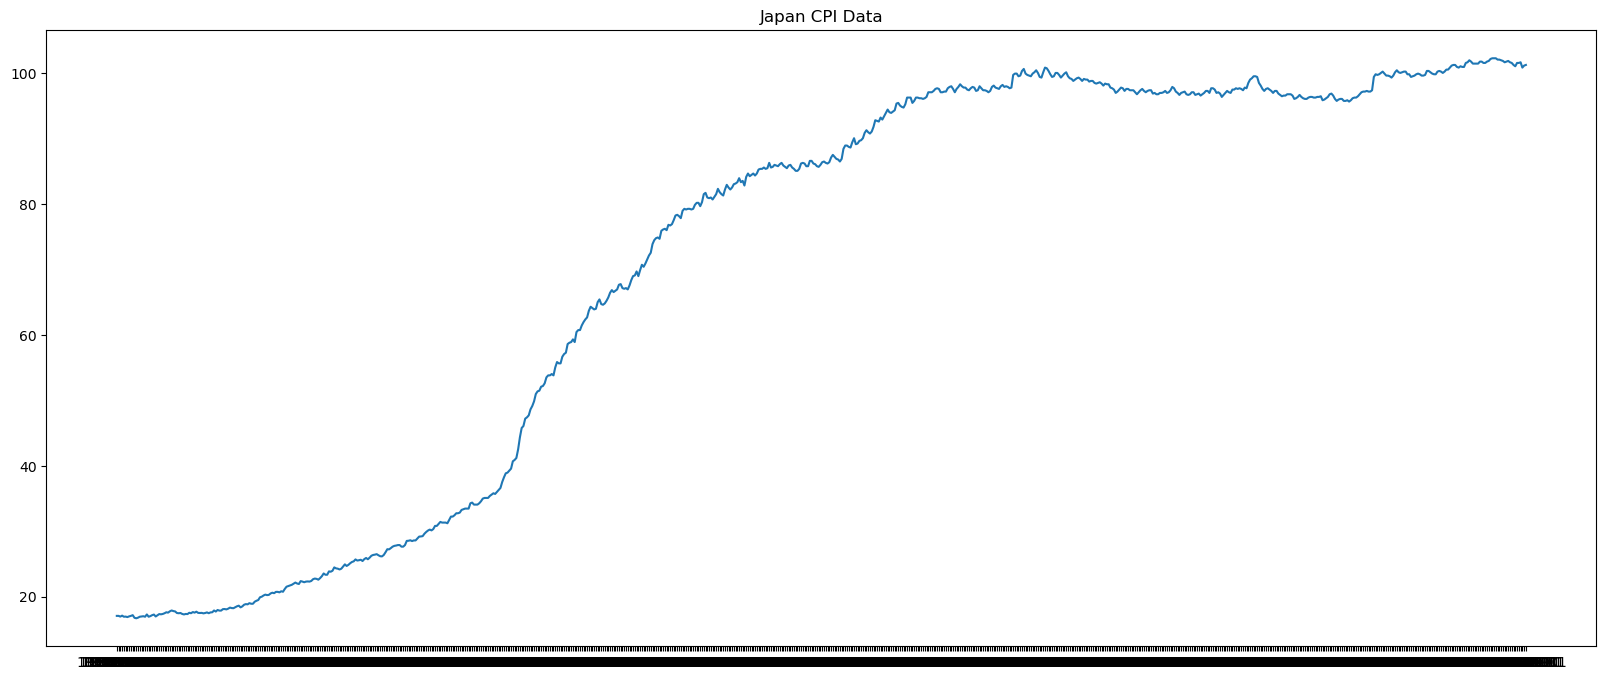

In [6]:
plt.figure(figsize = (20,8))
plt.plot(cpi)
plt.title("Japan CPI Data")
plt.show()

The CPI's behavior changes dramatically over the full series. There's a steep climb through the early 1990s (Japan's high-growth and bubble era), then a flat stretch of near-zero inflation since. A single ARMA fit across both regimes would be misspecified, since the dynamics differ before and after that structural break. So, for the purposes of this demonstration, I'll restrict the analysis to 1990 onward, where the series seems more homogeneous. 

In [7]:
cpi = cpi.loc['1990-01-01':'2021-06-01']

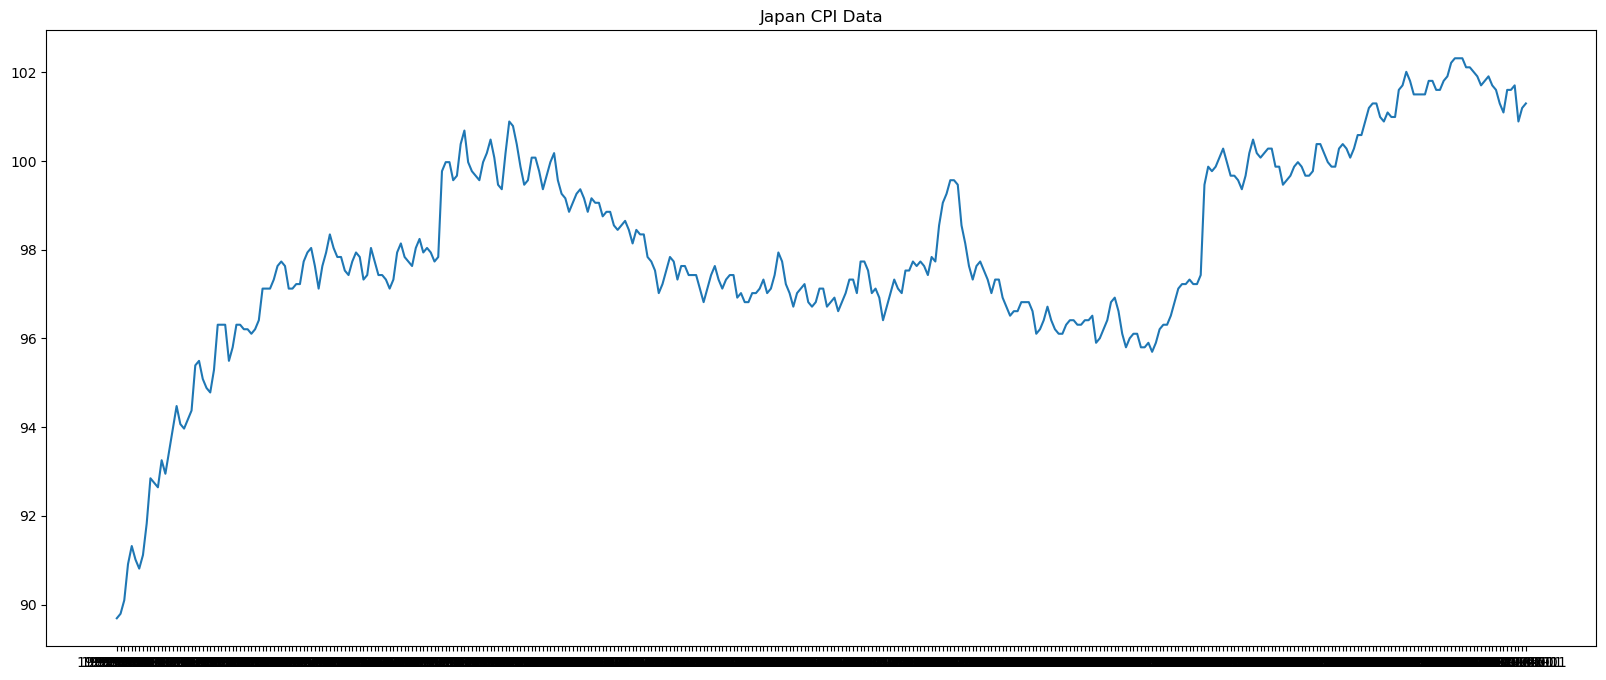

In [8]:
plt.figure(figsize = (20,8))
plt.plot(cpi)
plt.title("Japan CPI Data")
plt.show()

In [9]:
def perform_adf_kpss_test(series):
    result = adfuller(series)
    result2 = kpss(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('KPSS Statistic: %f' % result2[0])
    print('p-value: %f' % result2[1])

In [10]:
perform_adf_kpss_test(cpi["CPI"])

ADF Statistic: -2.091709
p-value: 0.247862
KPSS Statistic: 1.146348
p-value: 0.010000


/var/folders/2w/snn2ch354_s3_1yf6tsg1xb00000gn/T/ipykernel_29100/3657576640.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result2 = kpss(series)


- ADF p-value is >0.05, so fail to reject the null --> series has unit root (non-stationary)

- KPSS p-value is <0.05. so reject the null --> series is non-stationary 

The stationarity tests agree that our series is *non-stationary*. 

Since I know our series has a unit root from the ADF test, I'll take the log and difference to stabilize variance and remove this trend. 

This is a common transformation for indices data as log differencing also has a unique property: 
$$\ln(CPI_t) - \ln(CPI_{t-1}) = \ln\left(\frac{CPI_t}{CPI_{t-1}}\right) \approx \frac{CPI_t - CPI_{t-1}}{CPI_{t-1}}$$

So our by log differencing we're approximating the monthly inflation rate (percent change).

In [11]:
cpi["log_diff"] = np.log(cpi["CPI"]).diff()
cpi = cpi.dropna()
cpi.head()

,CPI,log_diff
observation_date,,
1990-02-01,89.79384,0.001134
1990-03-01,90.09926,0.003396
1990-04-01,90.91372,0.008999
1990-05-01,91.32095,0.004469
1990-06-01,91.01553,-0.003350


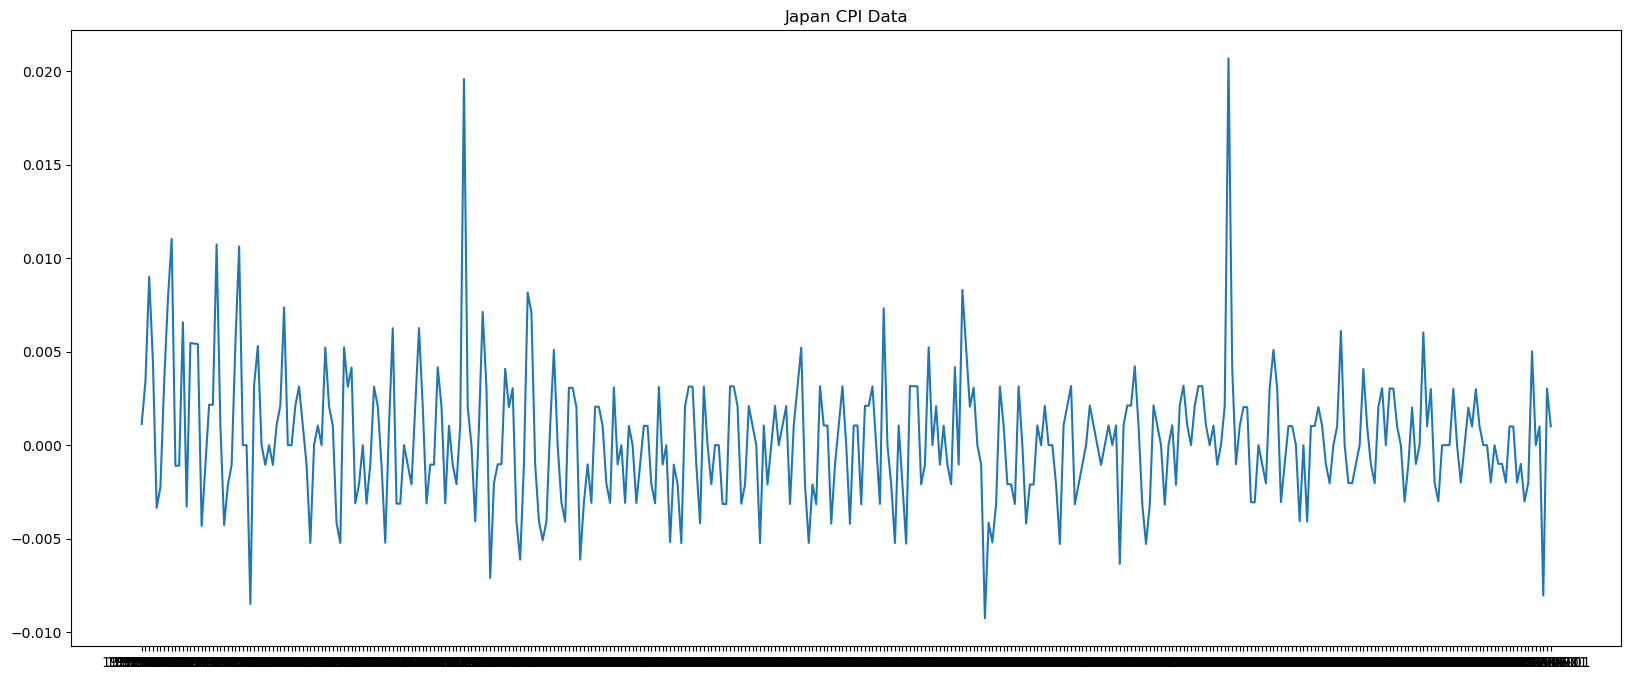

In [12]:
plt.figure(figsize = (20,8))
plt.plot(cpi["log_diff"])
plt.title("Japan CPI Data")
plt.show()

Now let's check the stationarity of our transformed series. 

In [13]:
perform_adf_kpss_test(cpi["log_diff"])

ADF Statistic: -4.282887
p-value: 0.000476
KPSS Statistic: 0.298000
p-value: 0.100000


/var/folders/2w/snn2ch354_s3_1yf6tsg1xb00000gn/T/ipykernel_29100/3657576640.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result2 = kpss(series)


- ADF p-value is <0.05, so reject the null --> series has no unit root (stationary)

- KPSS p-value is >0.05. so fail to reject the null --> series is stationary 

Stationarity tests agree that the series is stationary! 

With our transformed series now stationary, we can now move on to selecting and fitting an ARMA model to it.

### Model Identification - Finding p,q,P,Q


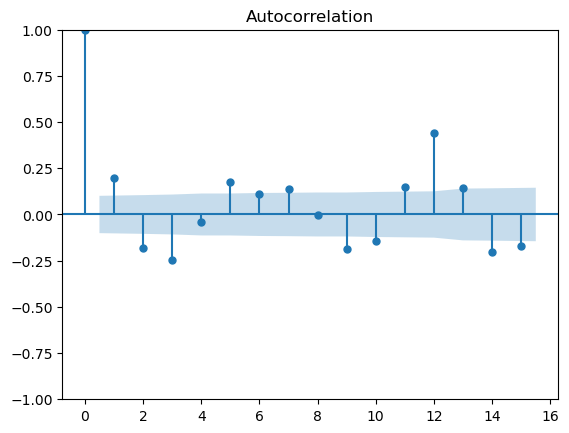

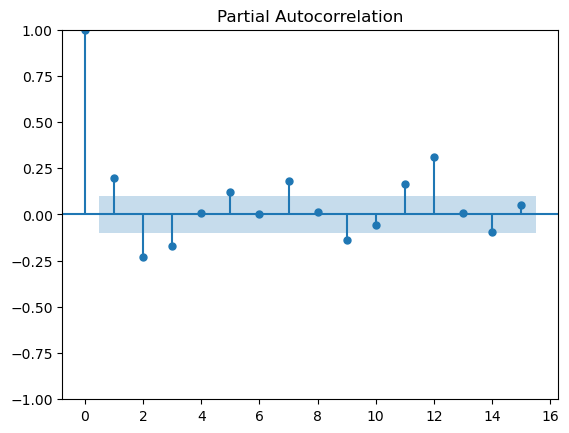

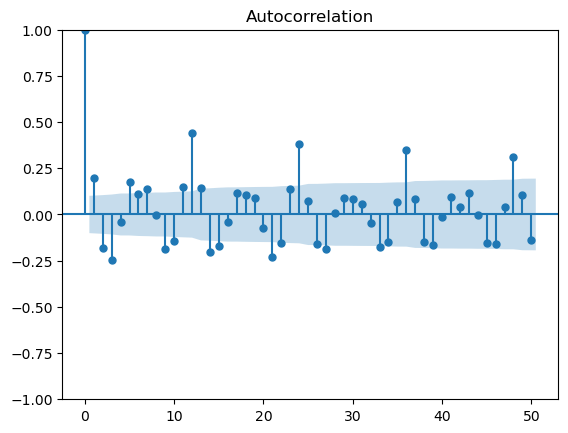

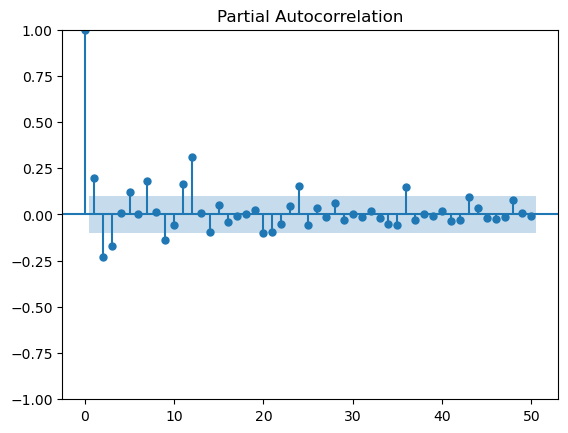

In [14]:
acf_plot = plot_acf(cpi.log_diff, lags = 15)
pacf_plot = plot_pacf(cpi.log_diff, lags = 15)
acf_plot = plot_acf(cpi.log_diff, lags = 50)
pacf_plot = plot_pacf(cpi.log_diff, lags = 50)

Choosing p, q (non-seasonal):

Looking at lags 1-11:

- ACF: spike at lag 1, negative spikes at lags 2 and 3, then within confidence bands -> cuts off after lag 3 -> suggests MA(3)
- PACF: spike at lag 1, negative spikes at lags 2 and 3, then within confidence bands -> cuts off after lag 3 -> suggests AR(3)
- When both ACF and PACF cut off at the same lag, the result is ambiguous: pure AR(3) or MA(3) are possible, but a more parsimonious ARMA(p,q) where $p + q \leq 3$ may be sufficient. We'll fit several candidates and let AIC/BIC decide.


Choosing P, Q (seasonal):

Looking at seasonal lags 12, 24, 36, 48:

- ACF: spikes at 12, 24, 36, 48 decaying gradually -> tails off
- PACF: significant spike at lag 12, decaying spikes at 24 and 36, within bands at 48 -> tails off
- Both ACF and PACF tail off at seasonal lags -> suggests a seasonal ARMA(P,Q) component with both P>0 and Q>0
- We'll include (P=1,Q=1) and (P=1,Q=0) and (P=0,Q=1) candidates and let AIC/BIC decide



### Model Selection and Validation

Since we have a lot of potential combinations of p, q, P, Q, we have a lot of candidate models to check. We'll use grid search to fit a model for each combination, and compare each model's AIC/BIC to see which one fits the best. 

In [15]:
from itertools import product
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

y = cpi["log_diff"] # current differenced series


# define search space
p_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 3]
P_values = [0, 1]
Q_values = [0, 1]


 
with warnings.catch_warnings(): # for suppressing convergence warnings
    warnings.simplefilter('ignore')

    results = {}

    for p, q, P, Q in product(p_values, q_values, P_values, Q_values):
        # skip pure noise model
        if p == 0 and q == 0 and P == 0 and Q == 0:
            continue
        try:
            model = SARIMAX(y, order=(p,0,q), seasonal_order=(P,0,Q,12))
            result = model.fit(disp=False)
            results[f'ARMA({p},{q})x({P},{Q})'] = (result.aic, result.bic)
            print(f'ARMA({p},{q})x({P},{Q})')
        except:
            pass  # skip models that fail to converge

ARMA(0,0)x(0,1)
ARMA(0,0)x(1,0)
ARMA(0,0)x(1,1)
ARMA(0,1)x(0,0)
ARMA(0,1)x(0,1)
ARMA(0,1)x(1,0)
ARMA(0,1)x(1,1)
ARMA(0,2)x(0,0)
ARMA(0,2)x(0,1)
ARMA(0,2)x(1,0)
ARMA(0,2)x(1,1)
ARMA(0,3)x(0,0)
ARMA(0,3)x(0,1)
ARMA(0,3)x(1,0)
ARMA(0,3)x(1,1)
ARMA(1,0)x(0,0)
ARMA(1,0)x(0,1)
ARMA(1,0)x(1,0)
ARMA(1,0)x(1,1)
ARMA(1,1)x(0,0)
ARMA(1,1)x(0,1)
ARMA(1,1)x(1,0)
ARMA(1,1)x(1,1)
ARMA(1,2)x(0,0)
ARMA(1,2)x(0,1)
ARMA(1,2)x(1,0)
ARMA(1,2)x(1,1)
ARMA(1,3)x(0,0)
ARMA(1,3)x(0,1)
ARMA(1,3)x(1,0)
ARMA(1,3)x(1,1)
ARMA(2,0)x(0,0)
ARMA(2,0)x(0,1)
ARMA(2,0)x(1,0)
ARMA(2,0)x(1,1)
ARMA(2,1)x(0,0)
ARMA(2,1)x(0,1)
ARMA(2,1)x(1,0)
ARMA(2,1)x(1,1)
ARMA(2,2)x(0,0)
ARMA(2,2)x(0,1)
ARMA(2,2)x(1,0)
ARMA(2,2)x(1,1)
ARMA(2,3)x(0,0)
ARMA(2,3)x(0,1)
ARMA(2,3)x(1,0)
ARMA(2,3)x(1,1)
ARMA(3,0)x(0,0)
ARMA(3,0)x(0,1)
ARMA(3,0)x(1,0)
ARMA(3,0)x(1,1)
ARMA(3,1)x(0,0)
ARMA(3,1)x(0,1)
ARMA(3,1)x(1,0)
ARMA(3,1)x(1,1)
ARMA(3,2)x(0,0)
ARMA(3,2)x(0,1)
ARMA(3,2)x(1,0)
ARMA(3,2)x(1,1)
ARMA(3,3)x(0,0)
ARMA(3,3)x(0,1)
ARMA(3,3)x(1,0)
ARMA(3,3

In [26]:
# top 5 by AIC
print("Top 5 by AIC:")
sorted_aic = sorted(results.items(), key=lambda x: x[1][0])
for name, (aic, bic) in sorted_aic[:5]:
    print(f'{name}: AIC={aic:.2f}, BIC={bic:.2f}')

# top 5 by BIC
print("\nTop 5 by BIC:")
sorted_bic = sorted(results.items(), key=lambda x: x[1][1])
for name, (aic, bic) in sorted_bic[:5]:
    print(f'{name}: AIC={aic:.2f}, BIC={bic:.2f}')

Top 5 by AIC:
ARMA(1,3)x(1,1): AIC=-3336.06, BIC=-3308.54
ARMA(0,1)x(1,1): AIC=-3327.38, BIC=-3311.65
ARMA(1,0)x(1,1): AIC=-3325.83, BIC=-3310.10
ARMA(1,1)x(1,1): AIC=-3324.94, BIC=-3305.27
ARMA(3,0)x(1,1): AIC=-3323.58, BIC=-3299.99

Top 5 by BIC:
ARMA(0,1)x(1,1): AIC=-3327.38, BIC=-3311.65
ARMA(1,0)x(1,1): AIC=-3325.83, BIC=-3310.10
ARMA(1,3)x(1,1): AIC=-3336.06, BIC=-3308.54
ARMA(0,0)x(1,1): AIC=-3320.07, BIC=-3308.27
ARMA(1,1)x(1,1): AIC=-3324.94, BIC=-3305.27


It looks like we have two potential winners. 
$ARMA(1,3)\times(1,1)_{12}$ has the lowest AIC and second-lowest BIC, while $ARMA(0,0)\times(1,1)_{12}$ has the lowest BIC and second-lowest AIC. 
Note, the difference in AIC between the two is ~0.82 which can be considered negligible, making $ARMA(0,0)\times(1,1)_{12}$ slightly more favorable (it's also more parsimonious). 


Still, I'll validate both to see if after running them our residuals are essentially white noise. I'll do this by running normality autocorrelation, and heteroskedasticity tests. 

In [27]:
# fitting the models 
best_model1 = SARIMAX(y, order=(1,0,3), seasonal_order = (1,0,1,12))
result1 = best_model1.fit(disp=False)

best_model2 = SARIMAX(y, order=(0,0,0), seasonal_order = (1,0,1,12))
result2 = best_model2.fit(disp=False)

/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmode

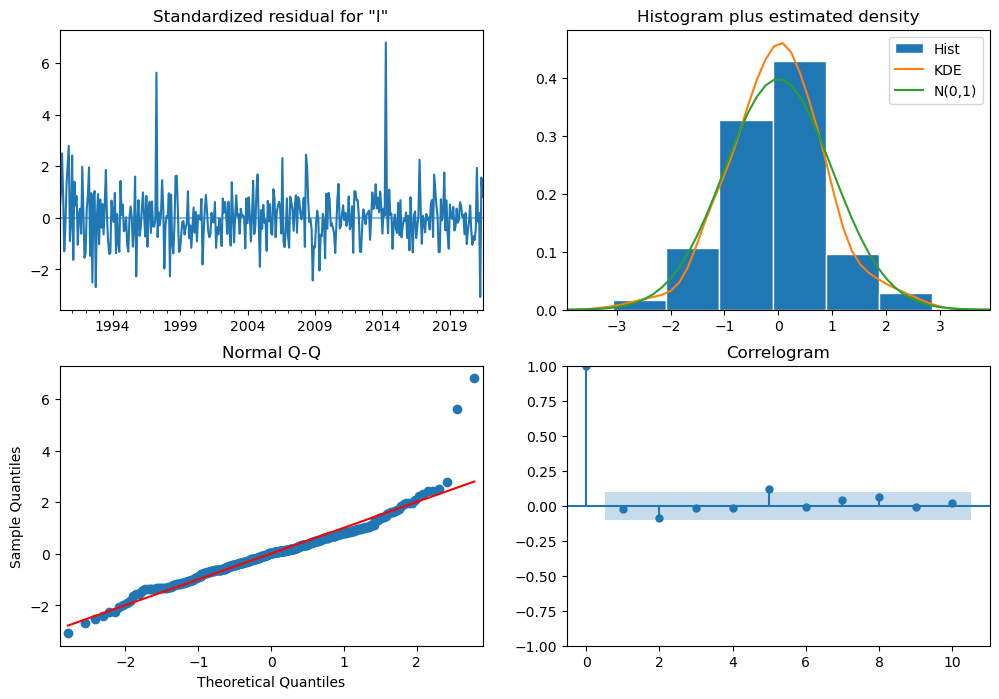

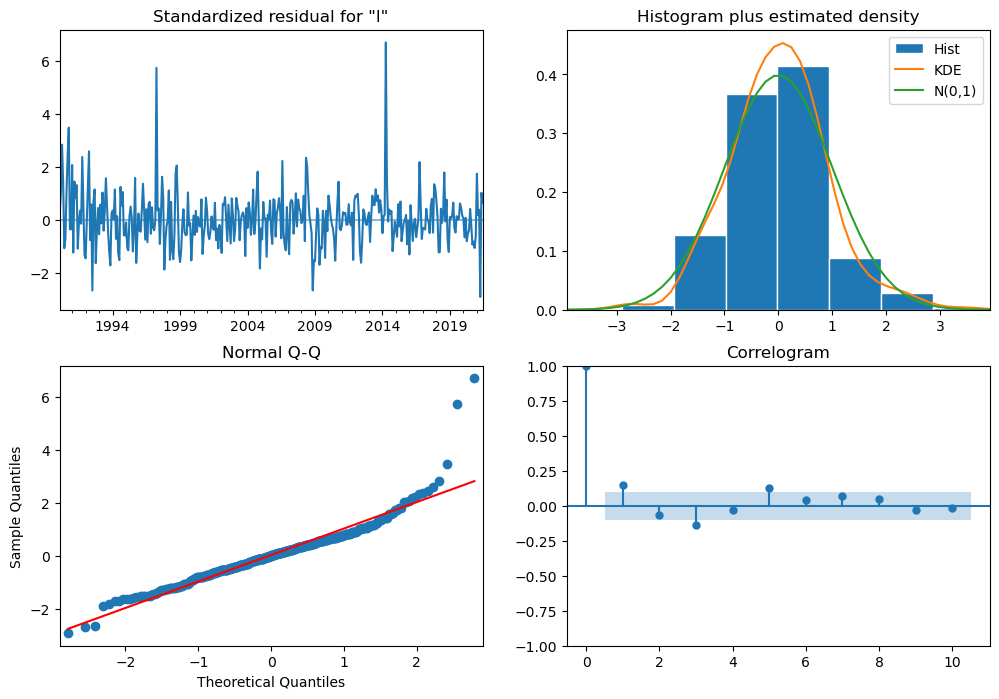

In [28]:
# visual checks
result1.plot_diagnostics(figsize=(12,8));
result2.plot_diagnostics(figsize=(12,8));

Looking at the residual diagnostic plots, both models look nearly identical:

- Residual ACF/PACF: both essentially show white noise
- Histogram: $ARMA(0,0)\times(1,1)_{12}$ looks slightly closer to normal, less skewed.
- QQ plot: both show heavy tails
- Correlogram: both have mostly non-significant autocorrelations, $ARMA(0,0)\times(1,1)_{12}$ looks like it has more lags outside the bands

Let's look more closely at the PACF/ACF plots: 

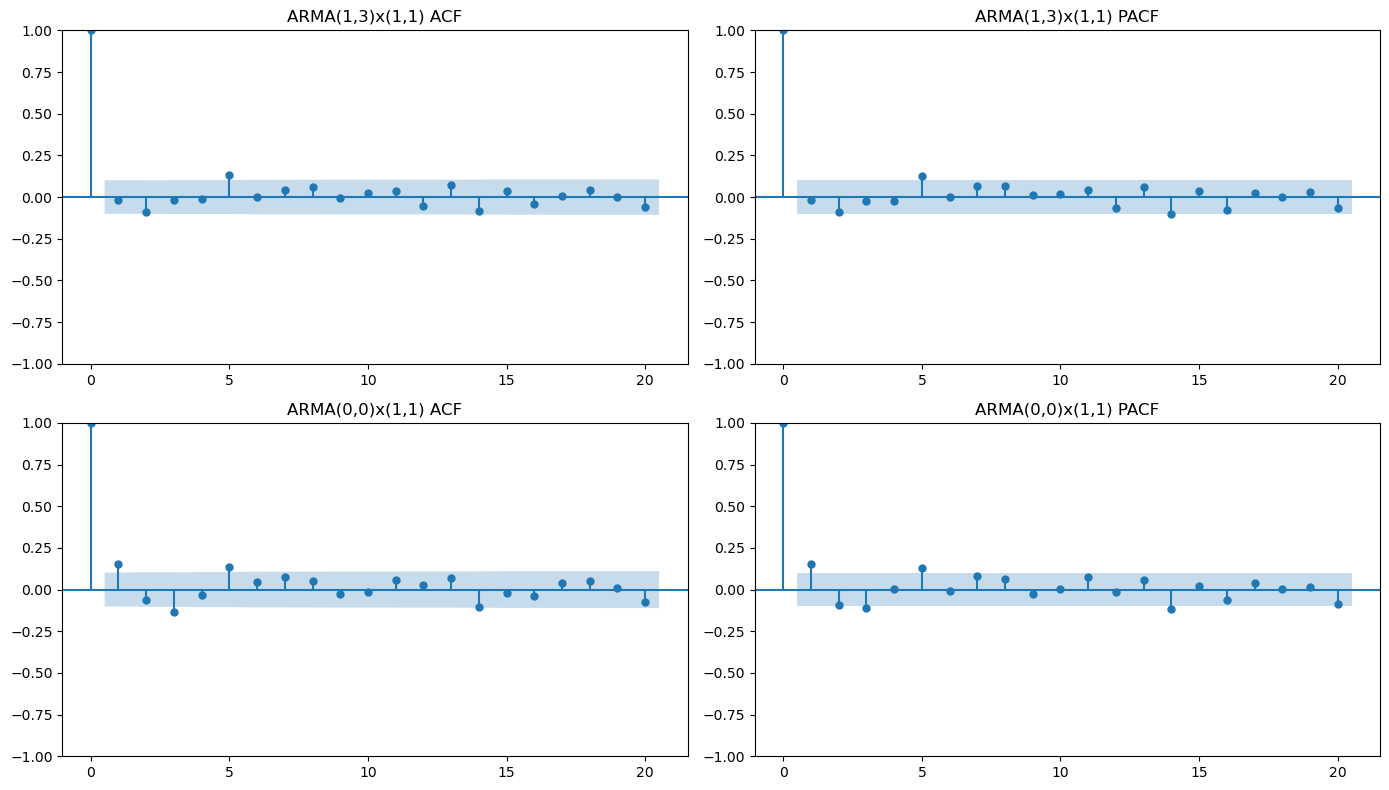

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(result1.resid, lags=20, ax=axes[0,0], title='ARMA(1,3)x(1,1) ACF')
plot_pacf(result1.resid, lags=20, ax=axes[0,1], title='ARMA(1,3)x(1,1) PACF')
plot_acf(result2.resid, lags=20, ax=axes[1,0], title='ARMA(0,0)x(1,1) ACF')
plot_pacf(result2.resid, lags=20, ax=axes[1,1], title='ARMA(0,0)x(1,1) PACF')

plt.tight_layout()
plt.show()

Looking at $ARMA(0,0)\times(1,1)_{12}$, lag 1 and lag 5 in both ACF and PACF are slightly outside the bands, suggesting some remaining short-run autocorrelation the model isn't capturing.
Meanwhile, for $ARMA(1,3)\times(1,1)_{12}$, only lag 5 in ACF and PACF is outside the bands. 

So while $ARMA(0,0)\times(1,1)_{12}$ is more parsimonious, the extra parameters in $ARMA(1,3)\times(1,1)_{12}$ are actually doing work by cleaning up those short-run lags, and thus seems to be the better model. 

To confirm definitively, let's run Jarque-Bera Test (for Normality), Ljung-Box Test (for Autocorrelation), and ARCH Test (for Heteroskedasticity) on each models' residuals.

In [30]:
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

 # jarque-bera
jb_stat1, jb_p1 = jarque_bera(result1.resid)
jb_stat2, jb_p2 = jarque_bera(result2.resid)

# ljung-box
lb1 = acorr_ljungbox(result1.resid.dropna(), lags=20) 
lb2 = acorr_ljungbox(result2.resid.dropna(), lags=20)

# ARCH
arch_stat1, arch_p1, _, _ = het_arch(result1.resid) 
arch_stat2, arch_p2, _, _ = het_arch(result2.resid) 

print("ARMA(1,3)x(1,1):")
print(f"Jarque-Bera:  stat={jb_stat1:.4f}, p={jb_p1:.4f}")
print(f"Ljung-Box:    min p={lb1.lb_pvalue.min():.4f}, any significant={( lb1.lb_pvalue < 0.05).any()}")
print(f"ARCH-LM:      stat={arch_stat1:.4f}, p={arch_p1:.4f}")

print("\nARMA(0,0)x(1,1):")
print(f"Jarque-Bera:  stat={jb_stat2:.4f}, p={jb_p2:.4f}")
print(f"Ljung-Box:    min p={lb2.lb_pvalue.min():.4f}, any significant={( lb2.lb_pvalue < 0.05).any()}")
print(f"ARCH-LM:      stat={arch_stat2:.4f}, p={arch_p2:.4f}")


ARMA(1,3)x(1,1):
Jarque-Bera:  stat=904.5868, p=0.0000
Ljung-Box:    min p=0.0783, any significant=False
ARCH-LM:      stat=1.7974, p=0.9977

ARMA(0,0)x(1,1):
Jarque-Bera:  stat=986.0906, p=0.0000
Ljung-Box:    min p=0.0002, any significant=True
ARCH-LM:      stat=1.6878, p=0.9982


For $ARMA(1,3)\times(1,1)_{12}$: 
- Jarque-Bera: p < 0.05 -> reject H0, residuals are *not* normally distributed. This is quite normal for financial data, and not a deal-breaker when it comes to if our model is a good fit or not. Looking at the Normality plot, I could see that for the most part, the residuals are fine, except for the heavy tails.
- Ljung-Box: p > 0.05 at all lags -> fail to reject H0 -> residuals are white noise! 
- ARCH: p > 0.05 -> fail to reject H0 -> no ARCH effects are present!

For $ARMA(0,0)\times(1,1)_{12}$: 
- Jarque-Bera: p < 0.05 -> reject H0, residuals are *not* normally distributed. Same as with the other model. 
- Ljung-Box: p < 0.05 at one or more lags -> reject H0 -> residuals are *not* white noise. 
- ARCH: p > 0.05 -> fail to reject H0 -> no ARCH effects are present!



So while $ARMA(0,0)\times(1,1)_{12}$ was favored by BIC, nearly equivalent on AIC, and is more parsimonious,  the Ljung-Box test definitively rules it out: a lag with a p-value of 0.0027 means we can reject the null of white noise residuals with very high confidence, indicating the model is leaving meaningful autocorrelation unexplained. 

So I can say confidently that $ARMA(1,3)\times(1,1)_{12}$ is our best model as it is the only candidate that passes all three diagnostic tests.


## ARIMA to State-Space

Now, for the purposes of demonstration, let's convert our ARMA to state-space form. 

In order to use one of Harvey's, Akaike's, or Aoki's approaches, we first need to convert our $ARMA(1,3)\times(1,1)_{12}$ to a simpler, standard non-seasonal $ARMA(p,q)$ representation. We do this by expanding out $ARMA(1,3)\times(1,1)_{12}$. 

$ARMA(1,3)\times(1,1)_{12}:$

$$(1 - \phi_1B)(1 - \Phi_1B^{12})y_t = (1 + \theta_1B + \theta_2B^2 + \theta_3B^3)(1 + \Theta_1B^{12})\epsilon_t$$

multiplying out both sides' polynomials: 

AR side: 
$$(1 - \phi_1B)(1 - \Phi_1B^{12}) = 1 - \phi_1B - \Phi_1B^{12} + \phi_1\Phi_1B^{13}$$

$$y_t =  \phi_1y_{t-1} + \Phi_1y_{t-12} - \phi_1\Phi_1y_{t-13} + (MA \, terms)$$
-> AR with lags 1, 12, 13

MA side: 
$$(1 + \theta_1B + \theta_2B^2 + \theta_3B^3)(1 + \Theta_1B^{12}) = 1 + \theta_1B + \theta_2B^2 + \theta_3B^3 + \Theta_1B^{12} + \theta_1\Theta_1B^{13} + \theta_2\Theta_1B^{14} + \theta_3\Theta_1B^{15}$$
-> MA with lags 1, 2, 3, 12, 13, 14, 15

So we can rewrite our model as ARMA(13, 15), where most of the intermediate coefficients are zero. 
This is what we'll feed into our state-space conversion.

### Let's use Harvey's Approach

Recall that to use this method, we need to rewrite the $ARMA(p,q)$ as $ARMA(m, m - 1)$, where m will be the dimension of our state-space vector and $m = max(p, q +1)$: 

$$ 
y_t = \sum_{i=1}^{m} \phi_iy_{t-i} + a_t - \sum_{j=1}^{m-1} \theta_ja_{t-j}
$$

with 

- $\phi_i = 0$ for i > p

- $\theta_j = 0$ for j > q


So with $ARMA(13, 15)$, $m = 16$, so $ARMA(m, m-1) = ARMA(16,15)$ (AR polynomial gets padded with zeros at lag 14, 15, 16 since our original AR only goes to lag 13). Our state vector is length 16. 

Harvey's approach is as follows: 

**Observation Equation:** 
    
$$ 
y_t = \underbrace{\begin{bmatrix} 1, 0, 0 \dots, 0 \end{bmatrix}}_{Z}
\underbrace{\begin{bmatrix} y_t \\ s_{2,t}  \\ \vdots \\ s_{m-1,t} \\ s_{m,t}\end{bmatrix}}_{s_t}
$$

**State Equation:**


$$ 
\underbrace{\begin{bmatrix} y_{t+1} \\ s_{2,t+1} \\ \vdots \\ s_{m-1,t+1} \\ s_{m,t + 1}\end{bmatrix}}_{s_{t+1}} = 
\underbrace{\begin{bmatrix} \phi_1 & 1 & 0 & \cdots & 0 \\ \phi_2 & 0 & 1 & \cdots & 0\\ \vdots & \vdots & \vdots & \ddots & \vdots  \\ \phi_{m-1}& 0 & 0 & \cdots & 1 \\ \phi_m & 0 & 0 & \cdots & 0 \end{bmatrix}}_{T}
\underbrace{\begin{bmatrix} y_t \\ s_{2,t}  \\ \vdots \\ s_{m-1,t} \\ s_{m,t}\end{bmatrix}}_{s_t}+ 
\underbrace{\begin{bmatrix} 1 \\ -\theta_{1}  \\ \vdots \\ -\theta_{m-2} \\ -\theta_{m-1}\end{bmatrix}}_{R}
\underbrace{a_{t+1}}_{\eta_t}
$$


All we need to do is construct the transition and noise routing matrices, T and R, with the coefficients from our fitted ARMA (expansion-form) model, as well as Z (observation loadings matrix) and Q (state noise covariance matrix) (note: H, the measurement noise covariance matrix is 0 as noise enters through R in Harvey's form). 

The state matrix $s_t$ is what we'll estimate later using the Kalman filter. 

In [31]:
result1.params

ar.L1       0.284922
ma.L1      -0.110239
ma.L2       0.039863
ma.L3      -0.098611
ar.S.L12    0.891206
ma.S.L12   -0.602917
sigma2      0.000008
dtype: float64

In [32]:
# get AR coefficients

AR1 = result1.params.iloc[0] # phi_1 
AR2_11 = [0]*10 # coeffs for lags 2-11 are 0
AR12 = result1.params.iloc[4] # Phi_1
AR13 = -result1.params.iloc[0]*result1.params.iloc[4] # -phi_1*Phi_1
AR14_16 = [0]*3 # coeffs for lags 14-16 are also 0

ar_coeffs = (
    [AR1] +        # lag 1
    AR2_11 +       # lags 2-11 (zeros)
    [AR12] +       # lag 12
    [AR13] +       # lag 13
    AR14_16        # lags 14-16 (zeros)
)

ar_coeffs = np.array(ar_coeffs)
print(ar_coeffs)
print(len(ar_coeffs))

[ 0.2849  0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.8912 -0.2539  0.      0.      0.    ]
16


In [34]:
# get MA coefficeients 
MA1 = result1.params.iloc[1] # theta_1 
MA2 = result1.params.iloc[2] # theta_2
MA3 = result1.params.iloc[3] # theta_3
MA4_11 = [0]*8 # coeffs for lags 4-11 are 0 
MA12 = result1.params.iloc[5] # Theta_1
MA13 = result1.params.iloc[1]*result1.params.iloc[5] # theta_1*Theta_1
MA14 = result1.params.iloc[2]*result1.params.iloc[5] # theta_2*Theta_1
MA15 = result1.params.iloc[3]*result1.params.iloc[5] # theta_3*Theta_1

ma_coeffs = (
    [MA1] +        # lag 1
    [MA2] +        # lag 2
    [MA3] +        # lag 3
    MA4_11 +       # lags 4-11 (zeros)
    [MA12] +       # lag 12
    [MA13] +       # lag 13
    [MA14] +       # lag 14 
    [MA15]         # lag 15
    
)

ma_coeffs = np.array(ma_coeffs)
print(ma_coeffs)
print(len(ma_coeffs))

[-0.1102  0.0399 -0.0986  0.      0.      0.      0.      0.      0.      0.      0.     -0.6029  0.0665 -0.024   0.0595]
15


In [35]:
# construct T Matrix

# 15x15 identity matrix
ones = [1]*15
identity = np.diag(ones)

# add 1x15 0 row at bottom
zeroes = np.zeros((1, 15))

arr = np.vstack([identity, zeroes])
ar_col = ar_coeffs.reshape(16, 1)

# combine 16x1 AR Coefficient col with 16x15 identity+0-row matrix
T = np.hstack([ar_col, arr])

In [36]:
np.set_printoptions(linewidth=200, precision=4, suppress=True)
print(T)
print(T.shape)

[[ 0.2849  1.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      1.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      1.      0.      

In [37]:
# construct R Matrix 

# add 1 to MA Coefficient col
R = np.append(1, ma_coeffs).reshape(16,1)  # statsmodels MA coeffs as-is, no *-1

print(R)
print(R.shape)

[[ 1.    ]
 [-0.1102]
 [ 0.0399]
 [-0.0986]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [ 0.    ]
 [-0.6029]
 [ 0.0665]
 [-0.024 ]
 [ 0.0595]]
(16, 1)


Note on sign convention: Tsay writes MA terms as subtracted ($y_t = \cdots + a_t - \sum_j \theta_j a_{t-j}$), giving $R = [1, -\theta_1, \dots]'$. But `statsmodels` adds them ($+\sum_j \theta_j a_{t-j}$), so its reported coefficients already carry the flipped sign. In Harvey's method, R requires negative MA coefficients. We plug them into $R$ as-is, as negating would double-flip and break the correspondence.

In [38]:
# construct Z Matrix
Z = np.zeros((1, 16))
Z[0, 0] = 1
print(Z)
print(Z.shape)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(1, 16)


In [39]:
# construct Q Matrix
Q = result1.params['sigma2']
print(Q)

7.938935901089433e-06


With our T, R, Z, and Q matrices completed, we now have a full state-space representation of our $ARMA(1,3)\times(1,1)_{12}$ model!

The next step is to run the Kalman filter and smoother to obtain $s_{t|T}$ - the smoothed state vector. From this we can extract $\hat{y}_{t|T} = Zs_{t|T}$, the smoothed estimate of the series, which can be used for interpolating missing values and generating forecasts with proper uncertainty bounds.

### Running the Kalman Filter and Smoother

For General Linear State-Space Models, the Kalman Filter algorithm is: 

At each time step $t = 1, \dots, T$ we run 7 equations in order:

$$ v_t = y_t - c_t- Z_ts_{t|t-1} \tag{compute innovation/forecast error}$$ 

$$ V_t = Z_t\Sigma_{t|t-1}Z'_t + H_t \tag{compute innovation variance}$$ 

$$ K_t = \frac{T_t\Sigma_{t|t-1}Z'_t}{V_t} \tag{Kalman Gain}$$ 

$$ s_{t|t} = s_{t|t-1}  + \frac{C_t}{V_t}v_t,\qquad C_t = \Sigma_{t|t-1}Z'_t \tag{update state estimate}$$ 

$$ \Sigma_{t|t} = \Sigma_{t|t-1}  - C_tV^{-1}_tC'_t \tag{update state uncertainty}$$ 



$$ s_{t+1|t} = d_t + T_ts_{t|t}  \tag{predict state estimate at t + 1}$$ 

$$ \Sigma_{t+1|t} = T_t\Sigma_{t|t}T'_t + R_tQ_tR'_t \tag{predict state uncertainty at t + 1 }$$ 



For Harvey's representation, we know $c_t$, $d_t$, $H_t$ are 0 and that $Q_t$ is a scalar equaling $\sigma^2_\eta$, so our Kalman Filter algorithm simplifies to: 

$$ v_t = y_t - Z_ts_{t|t-1} \tag{compute innovation/forecast error}$$ 

$$ V_t = Z_t\Sigma_{t|t-1}Z'_t \tag{compute innovation variance}$$ 

$$ K_t = \frac{T_t\Sigma_{t|t-1}Z'_t}{V_t} \tag{Kalman Gain}$$ 

$$ s_{t|t} = s_{t|t-1}  + \frac{C_t}{V_t}v_t,\qquad C_t = \Sigma_{t|t-1}Z'_t \tag{update state estimate}$$ 

$$ \Sigma_{t|t} = \Sigma_{t|t-1}  - C_tV^{-1}_tC'_t \tag{update state uncertainty}$$ 



$$ s_{t+1|t} = T_ts_{t|t}  \tag{predict state estimate at t + 1}$$ 

$$ \Sigma_{t+1|t} = T_t\Sigma_{t|t}T'_t + \sigma^2_\eta R_tR'_t \tag{predict state uncertainty at t + 1 }$$ 





First, we'll diffuse initialize $\Sigma_{1|0}$ and $s_{1|0}$ before runing our filter. 
We'll set: 

- $\Sigma_{1|0} = \infty$ (large value like $10^6$)
- $s_{1|0}$ = arbitrary value (like 0)

After one time step, these initializations will be washed out by the data:

after the first time step, 

- $K_1 = \frac{T_1\Sigma_{1|0}Z_1'}{V_1} = \frac{T_1\Sigma_{1|0}Z_1'}{Z_1\Sigma_{1|0}Z_1'} \approx \frac{T_1 Z_1'}{Z_1 Z_1'}$

- $s_{1|1} = s_{1,0} + \frac{\Sigma_{1|0}Z'_1}{V_1}v_1 =s_{1,0} +  \frac{\Sigma_{1|0}Z'_1}{Z_1\Sigma_{1|0}Z'_1}(y_1 - Z_1s_{1|0}) = s_{1,0} +  \approx\frac{1}{Z_1}(y_1 - Z_1s_{1|0}) \approx y_1$

- $\Sigma_{1|1} = \Sigma_{1|0} - \frac{\Sigma_{1|0}Z_1'(\Sigma_{1|0}Z_1')'}{Z_1\Sigma_{1|0}Z_1'} = \Sigma_{1|0} - \frac{\Sigma_{1|0}Z_1'Z_1\Sigma_{1|0}}{Z_1\Sigma_{1|0}Z_1'} = \Sigma_{1|0}\left(1 - \frac{Z_1'Z_1\Sigma_{1|0}}{Z_1\Sigma_{1|0}Z_1'}\right) \approx \Sigma_{1|0}(1 - 1) \approx 0$

and

- $s_{2|1} = T_1 s_{1|1} \approx T_1 y_1$

- $\Sigma_{2|1} = T_1\Sigma_{1|1}T_1' + \sigma_\eta^2 R_1 R_1' \approx T_1 \cdot 0 \cdot T_1' + \sigma_\eta^2 R_1 R_1' = \sigma_\eta^2 R_1 R_1'$

Note: this full wash-out happens after just one step for the directly observed component $s_{1,t}= y_t$, but for an
m-dimensional state vector, the remaining components wash out recursively through T over the next m−1 steps.

### Prediction Error Decomposition of the Likelihood - Estimation of $\sigma^2_\eta$

But wait! Before we can go ahead with our Kalman filter, we need to know $H_t$ and $T_t$, which means we need $\hat\sigma^2_\eta$ and $\hat\sigma^2_\epsilon$
(in this case, we actually know $H_t = 0$, so we really only need $\hat\sigma^2_\eta$, but generally this method solves for both).


In a normal setting, we could maximize the log likelihood function to get our parameter estimate: 

$$\log{L(\sigma_\eta^2})  = -\frac{T}{2}\log 2\pi - \frac{1}{2}\sum_{t=1}^T \log V_t - \frac{1}{2}\sum_{t=1}^T \frac{v_t^2}{V_t}$$

But there's a chicken-and-egg problem here: $v_t$, $V_t$ come from the Kalman filter, which requires $\sigma_\eta^2$

The solution is to optimize numerically:

1. Guess values of $\sigma_\eta^2$
2. Run the Kalman filter, get $v_t$, $V_t$ at each step
3. Evaluate the likelihood
4. Try a new candidate value that increases the likelihood
5. Repeat until convergence -> get $\hat\sigma^2_\eta$



In [40]:
def kalman_filter_likelihood(sigma_squared_eta, T, Z, R, y): 
    
    m = T.shape[0] # num of observation equations
    n = len(y) # num of time steps 

    # diffuse initialization
    s_pred = np.zeros((m, 1))  # (m x 1) 
    sig_pred = np.eye(m) * 1e6 # (m x m)

    log_likelihood = 0 

    y = y.values # convert to np array for clean referencing
    
    for t in range(n):
        
        # 1. innovation
        v = float((y[t] - Z @ s_pred).squeeze())
        
        # 2. variance of innovation
        V = float((Z @ sig_pred @ Z.T).squeeze())

        # accumulate log-likelihood:
        if t >= m:  # skip diffuse period: first m innovations reflect the 1e6 prior, not the model
            log_likelihood += -0.5 * (np.log(2 * np.pi) + np.log(V) + v**2 / V)
        
        # 3. Kalman gain
        C = sig_pred @ Z.T 
        K = T @ C / V 

        # 4. update state estimate
        s_filt = s_pred + (C/V) * v

        # 5. update state uncertainty
        sig_filt = sig_pred - (C/V) * C.T

        # 6. predict state at next step
        s_pred = T @ s_filt

        # 7. predict state uncertainty at next step
        sig_pred = T @ sig_filt @ T.T + sigma_squared_eta * R @ R.T
        
    return  log_likelihood


In [67]:

# our function to pass to the optimizer
def neg_log_likelihood(params, T, Z, R, y): 
    sigma2_eta = params[0]
    if sigma2_eta <= 0:  # keep variance positive
        return np.inf
    return -kalman_filter_likelihood(sigma2_eta, T, Z, R, y)
    # negative because minimizing negative log-likelihood == maximizing log-likelihood


from scipy.optimize import minimize

# numeric optimization 
result = minimize(
    neg_log_likelihood,
    x0=[1.0],  # initial sigma2_eta guess
    args=(T, Z, R, y), # additional params, fixed, not optimized over
    method='Nelder-Mead'
)


In [42]:
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1611.1613483988563
             x: [ 7.665e-06]
           nit: 45
          nfev: 90
 final_simplex: (array([[ 7.665e-06],
                       [ 7.659e-06]]), array([-1.611e+03, -1.611e+03]))


Quick sanity check.

Recall that $\sigma^2_a$ is the variance of the one-step-ahead forecast error of our ARMA process, what `statsmodels` reports as `sigma2`.

In theory, we should expect to see our estimate of $\sigma^2_\eta$ be equal to $\sigma^2_a$.

Why? When we write the ARMA in Harvey's state-space form, the state evolves as $s_{t+1}=T_ts_t+R_t\eta_t$, with $\eta_t \sim N(0, \sigma^2_\eta)$, and there's no separate observation noise (H = 0). So the only randomness entering the system is $\eta_t$. Harvey constructs the form specifically so that this single state shock *is* the ARMA innovation: $\eta_t = a_{t+1}$
They're the same random variable, so they have the same variance:
$$\sigma^2_\eta = \sigma^2_a$$

Compare that to a model that genuinely has two shocks.  Take the local level model from my last blog post: 
$$
y_t = \mu_t + e_t, \quad e_t \sim N(0, \sigma^2_e)
$$
$$
\mu_{t+1} = \mu_t + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)
$$

Here,  there are two independent shocks, state noise $\sigma^2_\eta$ and observation noise $\sigma^2_e$, so the single ARIMA innovation variance $\sigma^2_a$ is some *combination of both*. 
Harvey's form deliberately puts all the noise into the state equation and leaves the observation equation noise-free (H=0)!

So technically, we didn't even need to do Prediction Error Decomposition of the Likelihood - I could have just taken $\sigma^2_a$ from our ARIMA result to start with. But this was good practice, wasn't it? 

In [43]:
# compare parameters

print(result1.params['sigma2']) # statsmodels ARIMA output
print(result.x[0]) # prediction error decomposition optimization result


7.938935901089433e-06
7.665157317227064e-06


The two estimates are very very close! `statsmodels` uses exact diffuse initialization and fits all parameters jointly, while we use an approximate diffuse init (large initial variance) and optimize $\sigma^2_\eta$ alone. These treat the early sample slightly differently, so the maximizers don't coincide exactly - but the proximity confirms we're recovering the same innovation variance! 

I'll go ahead and use the ARIMA output as $\sigma^2_\eta$ for my Kalman filter. 

In [44]:
sigma_squared_eta = result1.params['sigma2']

In [45]:
def kalman_filter(sigma_squared_eta, T, Z, R, y): 
    
    m = T.shape[0] # num of observation equations
    n = len(y) # num of time steps 


    # storage
    v_all = np.zeros(n) # innovations (scalar each step)
    V_all = np.zeros(n) # innovation variances (scalar each step)
    K_all = np.zeros((n, m, 1)) # Kalman gains (m x 1 each step) 
    s_filt_all   = np.zeros((n, m)) # filtered states s_{t|t} (m x 1 each step)
    sig_filt_all = np.zeros((n, m, m)) # filtered covariances Sigma_{t|t} (m x m each step)
    s_pred_all   = np.zeros((n, m))  # predicted states s_{t|t-1} (m x 1 each step)
    sig_pred_all = np.zeros((n, m, m)) # predicted covariances Sigma_{t|t-1} (m x m each step)

    # diffuse initialization
    s_pred = np.zeros((m, 1))  # (m x 1) 
    sig_pred = np.eye(m) * 1e6 # (m x m)
    
    
    y = y.values # convert to np array for clean referencing
    
    for t in range(n):
        
        # store predicted
        s_pred_all[t]   = s_pred.flatten()
        sig_pred_all[t] = sig_pred

        # 1. innovation
        v = float((y[t] - Z @ s_pred).squeeze())
        v_all[t] = v 
        
        # 2. variance of innovation
        V = float((Z @ sig_pred @ Z.T).squeeze())
        V_all[t] = V
        
        # 3. Kalman gain
        C = sig_pred @ Z.T 
        K = T @ C / V 
        K_all[t] = K  

        # 4. update state estimate
        s_filt = s_pred + (C/V) * v

        # 5. update state uncertainty
        sig_filt = sig_pred - (C/V) * C.T

        # store filtered
        s_filt_all[t]   = s_filt.flatten()
        sig_filt_all[t] = sig_filt

        
        # 6. predict state at next step
        s_pred = T @ s_filt

        # 7. predict state uncertainty at next step
        sig_pred = T @ sig_filt @ T.T + sigma_squared_eta * R @ R.T

    return(v_all, V_all, K_all, s_filt_all, sig_filt_all, s_pred_all, sig_pred_all)

In [46]:
v_all, V_all, K_all, s_filt_all, sig_filt_all, s_pred_all, sig_pred_all = kalman_filter(sigma_squared_eta, T, Z, R, y)

In [47]:
# Check if values are stored correctly
# 1. shapes
print("v_all:", v_all.shape)          # (n,)
print("V_all:", V_all.shape)          # (n,)
print("K_all:", K_all.shape)          # (n, m, 1)
print("s_filt_all:", s_filt_all.shape)    # (n, m)
print("sig_filt_all:", sig_filt_all.shape) # (n, m, m)
print("s_pred_all:", s_pred_all.shape)    # (n, m)
print("sig_pred_all:", sig_pred_all.shape) # (n, m, m)

# 2. nothing left unwritten (all-zero rows would signal a skipped step)
print("v written:", not np.all(v_all == 0))
print("V positive:", np.all(V_all > 0))        # variances must be > 0
print("K written:", not np.all(K_all == 0))

# 3. internal consistency — recompute each quantity from stored predicteds and check it matches
t = 100
Zr = Z
v_check = float((y.values[t] - Zr @ s_pred_all[t].reshape(-1,1)).squeeze())
V_check = float((Zr @ sig_pred_all[t] @ Zr.T).squeeze())
K_check = (T @ sig_pred_all[t] @ Zr.T / V_check)

print("v matches:", np.isclose(v_all[t], v_check))
print("V matches:", np.isclose(V_all[t], V_check))
print("K matches:", np.allclose(K_all[t], K_check))

# 4. filtered vs predicted relationship
print("predict consistent:",
      np.allclose(s_pred_all[t], (T @ s_filt_all[t-1].reshape(-1,1)).flatten()))

v_all: (377,)
V_all: (377,)
K_all: (377, 16, 1)
s_filt_all: (377, 16)
sig_filt_all: (377, 16, 16)
s_pred_all: (377, 16)
sig_pred_all: (377, 16, 16)
v written: True
V positive: True
K written: True
v matches: True
V matches: True
K matches: True
predict consistent: True


### Let's Look at Our Kalman Filter Results

First, a quick correctness check. With Harvey's method, at each time step, the state vector $s_t$ has only one interpretable element: the first $s_{1,t} = y_t$. The remaining elements are recursively-defined auxiliary quantities with no standalone meaning. Because the observation equation is noise-free (H=0), the filter observes $y_t$ exactly (filtered value = actual value) - so the filtered first element should reproduce the data point-for-point. 


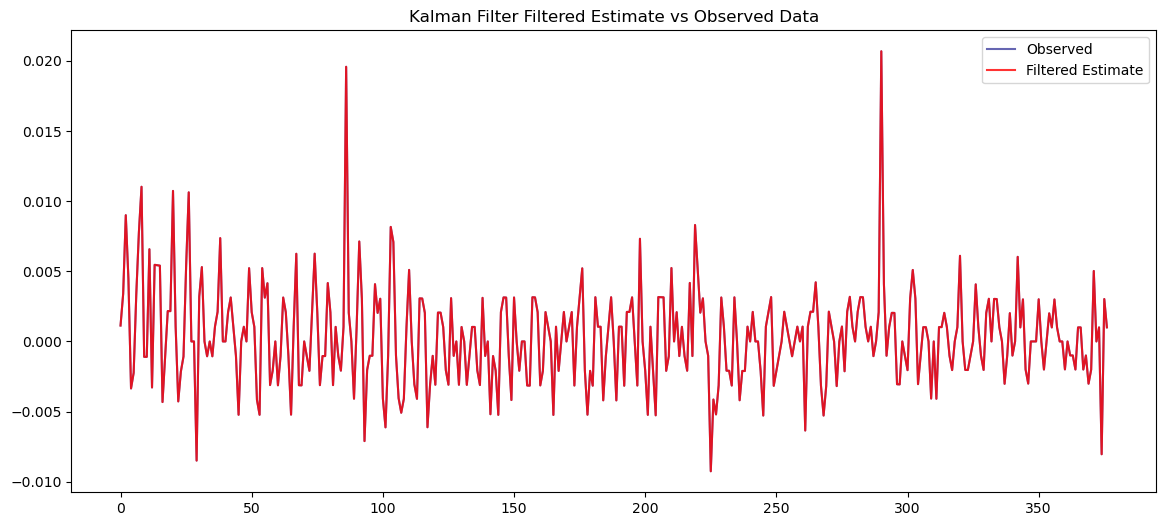

In [48]:
plt.figure(figsize=(14, 6))
plt.plot(y.values, color= 'navy', label='Observed', alpha=0.6)
plt.plot(s_filt_all[:, 0], color = 'red', label='Filtered Estimate', alpha=0.8)
plt.legend()
plt.title('Kalman Filter Filtered Estimate vs Observed Data')
plt.show()

Pretty boring, but the two curves coincide exactly, confirming our filter is implemented correctly!


Let's also look at our Kalman Filter's one-step ahead predictions.

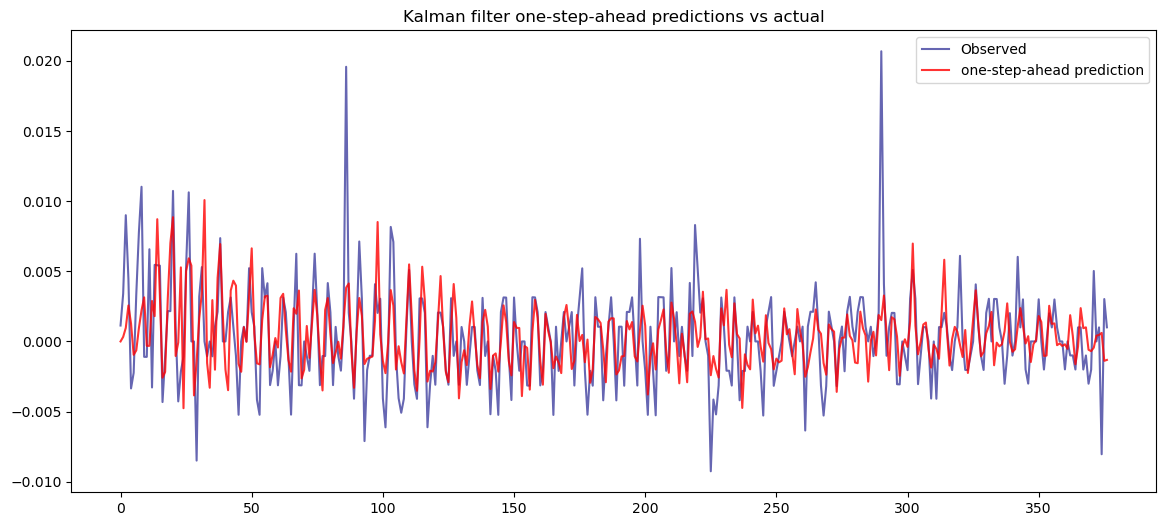

In [49]:
plt.figure(figsize=(14, 6))
plt.plot(y.values, color= 'navy', label='Observed', alpha=0.6)
plt.plot(s_pred_all[:, 0], color = 'red', label='one-step-ahead prediction', alpha=0.8)
plt.legend()
plt.title('Kalman filter one-step-ahead predictions vs actual')
plt.show()

Unlike the filtered first state (which trivially returns $y_t$), the one-step-ahead prediction $\hat{y}_{t|t-1} = s_{1,t|t-1}$ uses only information through time $t−1$, so it's a genuine forecast at each point. We can see that the prediction line is a damped version of the observed series, so it captures the systematic structure — the seasonal pattern and short-run autocorrelation the model identified — while not chasing the large idiosyncratic spikes, which are unpredictable shocks. 

The real test is whether what the predictions *missed* (the innovations (one-step-ahead prediction error) $v_t = y_t - \hat{y_{t|t-1}}$) still contain predictable structure. If the model captured everything it could, the innovations should be white noise with no autocorrelation. We can confirm this with the residual ACF.

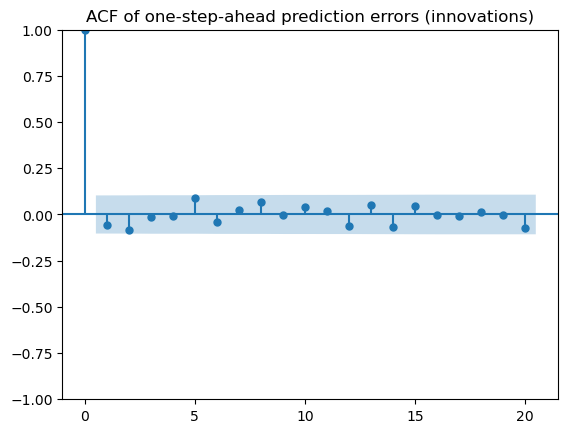

In [52]:
m = T.shape[0]

plot_acf(v_all[m:], lags=20)
plt.title('ACF of one-step-ahead prediction errors (innovations)')
plt.show()

The residuals have no significant autocorrelations. So our predictions extracted all the linearly-predictable structure, and what remains is genuinely unpredictable noise, which is exactly what we'd expect if the state-space filter is correctly reproducing the fitted ARIMA! 

For a final check, let's look at our filter's h-step-ahead predictions. 

### h-step ahead prediction 

Recall that for a local trend model, to predict $h$ time steps forward, our kalman algorithm simplified to

- $\mu_{T + h|T} = \mu_{T|T}$
- $\Sigma_{T + h|T} = \Sigma_{T|T} + h\sigma^2_{\eta}$

Since we have no observation $y_{T+h}$ to input, we skip the entire estimation step. Our estimates are not updated because there's no observation to change our belief, so we just run our predict steps $h$ times.

Then with our estimate of our hidden state at time T + h, our expected observation (forecast)  is
- $\hat{y}_{T+h} = E(\mu_{T+h}) + E(e_{T+h}) = \mu_{T+h|T} + 0 = \mu_{T+h|T}$

and our h-step ahead innovation and innovation variance are: 
- $v_{T+h} = y_{T+h} - \hat{y}_{T+h} = (\mu_{T+h} + e_{T+h}) - \mu_{T+h|T}$
    $= (\mu_{T+h} - \mu_{T+h|T}) + e_{T+h}$

- $V_{T+h} = Var(y_{T+h} - \hat{y}_{T+h}) = Var(\mu_{T+h} - \mu_{T+h|T}) + Var(e_{T+h})$

    $= Var(\mu_{T+h} \mid y_1, \dots, y_T) + \sigma_e^2$

  $= \Sigma_{T+h|T} + \sigma_e^2$

Plugging in $\mu_{T + h|T}$ and $\Sigma_{T+h|T}$, our h-step forecast of $y$ is 

- $\hat{y}_{T+h} = \mu_{T|T}$

    with forecast error variance
- $V_{T+h} = \Sigma_{T|T} + h\sigma^2_{\eta} + \sigma_e^2$

For a **general linear state-space model**, predicting $h$ steps forward works the same way. Since we have no observation $y_{T+h}$ to input, we skip the estimation step entirely — our estimates aren't updated because there's no observation to change our belief, so we just run the predict step $h$ times:

- $s_{T+h|T} = d_{T+h} + T_{T+h}\, s_{T+h-1|T}$
- $\Sigma_{T+h|T} = T_{T+h}\, \Sigma_{T+h-1|T}\, T_{T+h}' + R_{T+h} Q_{T+h} R_{T+h}'$

each step feeding on the previous prediction (for time-invariant $T$, $d=0$, this unrolls to $s_{T+h|T} = T^h s_{T|T}$).

Then with our hidden-state estimate at time $T+h$, the expected observation (forecast) is

- $\hat{y}_{T+h} = E(c_{T+h}) + E(Z_{T+h} s_{T+h}) + E(e_{T+h}) = c_{T+h} + Z_{T+h}\, s_{T+h|T}$

and our $h$-step-ahead innovation/forecast error and innovation variance are:

- $v_{T+h} = y_{T+h} - \hat{y}_{T+h} = (c_{T+h} + Z_{T+h} s_{T+h} + e_{T+h}) - (c_{T+h} + Z_{T+h} s_{T+h|T})$
  $= Z_{T+h}(s_{T+h} - s_{T+h|T}) + e_{T+h}$
- $V_{T+h} = \text{Var}(y_{T+h} - \hat{y}_{T+h}) = Z_{T+h}\, \text{Var}(s_{T+h} - s_{T+h|T})\, Z_{T+h}' + \text{Var}(e_{T+h})$
  $= Z_{T+h}\, \Sigma_{T+h|T}\, Z_{T+h}' + H_{T+h}$

So our $h$-step forecast is 

- $\hat{y}_{T+h} = c_{T+h} + Z_{T+h}\, s_{T+h|T}$

 with forecast error variance

- $V_{T+h} = Z_{T+h}\, \Sigma_{T+h|T}\, Z_{T+h}' + H_{T+h}$.



*Note* that we leave both the state and variance in recursive form here, since in the general case the system matrices may be time-varying — in which case iterating the recursion is the only option. When the system is time-invariant (as in Harvey's form below), the state collapses to the closed form $s_{T+h|T} = T^h s_{T|T}$. The variance, however, doesn't simplify cleanly even then — unlike the local trend case, where it collapsed to $\Sigma_{T|T} + h\sigma^2_\eta + \sigma^2_e$ — so we compute $\Sigma_{T+h|T}$ by iterating the recursion regardless.

*Also note*: If we set $Z = T = R = 1$, $d = c = 0$, $Q = \sigma^2_\eta$, $H = \sigma^2_e$ recovers the local trend formulas above!

$\hat{y}_{T+h} = \mu_{T|T}$ and $V_{T+h} = \Sigma_{T|T} + h\sigma^2_\eta + \sigma^2_e$


Since with Harvey's Approach, our T, R, and Z matrices are time invariant (built with fixed coefficients and don't change over time) with $d_t = 0$, $H_t = 0$, and $Q_t = \sigma^2_\eta$, our predict step and forecasts simplify as follows: 

- $s_{T+h|T} = T\, s_{T+h-1|T}$ which we can expand:

  $s_{T+h|T} = T\, s_{T+h-1|T} = T \cdot T\, s_{T+h-2|T} = \cdots = \underbrace{T \cdots T}_{h}\, s_{T|T} = T^h s_{T|T}$

- $\Sigma_{T+h|T} = T\,\Sigma_{T+h-1|T}\,T' + \sigma^2_\eta R\,R'$

$h$-step forecast:

- $\hat{y}_{T+h} = Z\,  T^h s_{T|T}$

forecast error variance (left in recursive form as it doesn't simplify cleanly):

- $V_{T+h} = Z\, \Sigma_{T+h|T}\, Z'$.

Let's predict 10 steps ahead. 

In [53]:
# get our last state vector and var at time t = T

last_s = s_filt_all[-1]
last_sig = sig_filt_all[-1]

print(last_s)
print(last_sig)

[ 0.001   0.0012  0.0011 -0.0006  0.0007 -0.0011 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0016 -0.0005  0.0002  0.0001]
[[ 0. -0. -0. -0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.]
 [ 0.  0. -0.  0. -0.  0. -0. -0.  0.  0.  0. -0.  0. -0.  0.  0.]
 [ 0. -0.  0. -0.  0. -0.  0. -0. -0. -0.  0.  0. -0.  0. -0. -0.]
 [ 0.  0. -0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0. -0. -0.]
 [ 0. -0.  0. -0.  0. -0.  0. -0. -0. -0. -0.  0. -0.  0.  0. -0.]
 [ 0.  0. -0.  0. -0.  0. -0.  0. -0. -0.  0.  0.  0. -0.  0.  0.]
 [ 0. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0. -0. -0.  0. -0.  0.]
 [ 0. -0. -0. -0. -0.  0. -0.  0. -0.  0. -0. -0.  0.  0.  0.  0.]
 [ 0.  0. -0. -0. -0. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0.  0.]
 [ 0.  0. -0.  0.  0.  0. -0.  0. -0.  0. -0.  0. -0. -0.  0. -0.]
 [ 0.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0. -0.  0. -0. -0.  0.]
 [ 0. -0.  0.  0. -0. -0.  0.  0. -0.  0. -0.  0. -0.  0. -0. -0.]
 [ 0.  0.  0.  0. -0. -0. -0. -0. -0. -0.  0. -0.  0. -0.  0. -0.]

In [54]:
def kalman_forecast(h, T, Z, R, sigma_squared_eta, last_s, last_sig):
    #last_s: s_{T|T}, shape (m, 1),  final filtered state
    # last_sig: Sigma_{T|T}, shape (m, m), final filtered covariance

    m = T.shape[0]

    # storage for the h forecasts
    y_forecast = np.zeros(h) # point forecasts  y_hat_{T+i}
    V_forecast = np.zeros(h) # forecast error variances
    s_fore_all = np.zeros((h, m)) # forecasted states s_{T+i|T}
    sig_fore_all = np.zeros((h, m, m))# forecasted covariances Sigma_{T+i|T}

    # start from the last filtered estimates
    s_pred = last_s
    sig_pred = last_sig

    for i in range(h):
        # predict one step forward
        s_pred = T @ s_pred
        sig_pred = T @ sig_pred @ T.T + sigma_squared_eta * R @ R.T

        # store state forecast and covariance
        s_fore_all[i] = s_pred.flatten()
        sig_fore_all[i] = sig_pred

        # forecast of y and its variance (H=0 in Harvey's form)
        y_forecast[i] = float((Z @ s_pred).squeeze())
        V_forecast[i] = float((Z @ sig_pred @ Z.T).squeeze())

    return y_forecast, V_forecast, s_fore_all, sig_fore_all

In [55]:
y_forecast, V_forecast, s_fore_all, sig_fore_all = kalman_forecast(10, T, Z, R, sigma_squared_eta, last_s, last_sig)

In [56]:
print(y_forecast)
print(V_forecast)
print(s_fore_all)
print(sig_fore_all)

[ 0.0015  0.0016 -0.0002  0.0007 -0.0009 -0.0008  0.0013 -0.0004  0.0002 -0.0018]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[[ 0.0015  0.0011 -0.0006  0.0007 -0.0011 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007 -0.0007  0.0002  0.0001  0.    ]
 [ 0.0016 -0.0006  0.0007 -0.0011 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006 -0.0002  0.0001  0.      0.    ]
 [-0.0002  0.0007 -0.0011 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006  0.0012 -0.0003  0.      0.      0.    ]
 [ 0.0007 -0.0011 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006  0.0012 -0.0004  0.      0.      0.      0.    ]
 [-0.0009 -0.0005  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006  0.0012 -0.0004  0.0007 -0.0002  0.      0.      0.    ]
 [-0.0008  0.0015 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006  0.0012 -0.0004  0.0007 -0.001   0.0002  0.      0.      0.    ]
 [ 0.0013 -0.0008  0.0003 -0.0018  0.0015 -0.0007  0.0006  0.0012 -0.0004  0.0007 -0.001  -0.0005  0

We can't really tell much from these outputs. Let's compare our 10 forecasts and forecast variances with `statsmodels`' built-in ARIMA forecasts. The results should match exactly. 


In [57]:
sm_fc = result1.get_forecast(10)
print("KF forecast:", np.round(y_forecast, 6))
print("statsmodels:", np.round(sm_fc.predicted_mean.values, 6))
print("KF variance:", np.round(V_forecast, 8))
print("statsmodels var:", np.round(sm_fc.var_pred_mean.values, 8))

KF forecast: [ 0.0015  0.0016 -0.0002  0.0007 -0.0009 -0.0008  0.0013 -0.0004  0.0002 -0.0018]
statsmodels: [ 0.0015  0.0016 -0.0002  0.0007 -0.0009 -0.0008  0.0013 -0.0004  0.0002 -0.0018]
KF variance: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
statsmodels var: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


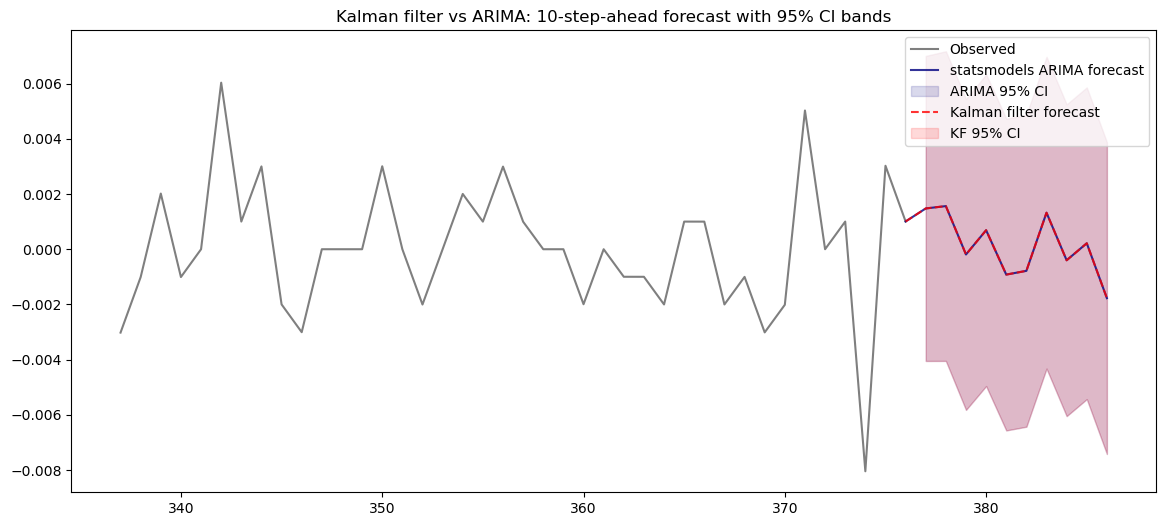

In [58]:
n = len(y)
h = 10
forecast_index = range(n, n + h)

fig, ax = plt.subplots(figsize=(14, 6))

# observed
ax.plot(range(n-40, n), y.values[-40:], color='black', label='Observed', alpha=0.5)

# statsmodels ARIMA forecast (anchored to last observed point)
ax.plot([n-1] + list(forecast_index),
        [y.iloc[-1]] + list(sm_fc.predicted_mean.values),
        label='statsmodels ARIMA forecast', color='navy', alpha=0.8)

# statsmodels CI band
ci = sm_fc.conf_int(alpha=0.05)
ax.fill_between(forecast_index, ci.iloc[:, 0], ci.iloc[:, 1],
                color='navy', alpha=0.15, label='ARIMA 95% CI')

# Kalman filter forecast (anchored to last observed point)
ax.plot([n-1] + list(forecast_index),
        [y.iloc[-1]] + list(y_forecast),
        label='Kalman filter forecast', color='red', linestyle='--', alpha=0.8)

# Kalman CI band
se = np.sqrt(V_forecast)
ax.fill_between(forecast_index,
                y_forecast - 1.96*se,
                y_forecast + 1.96*se,
                color='red', alpha=0.15, label='KF 95% CI')

ax.set_title("Kalman filter vs ARIMA: 10-step-ahead forecast with 95% CI bands")
ax.legend()
plt.show()

The forecasts and their variance/CIs are exactly the same! So this demonstrates how ARIMA model's predictions and forecasts can be exactly replicated using the state-space form and the Kalman filter.

### Kalman Missing Value Interpolation


Now let's look at something the state-space form enables that the classical ARIMA recursion can't: handling missing data. The standard ARIMA one-step recursion needs $y_{t−1},y_{t−2}, \dots$ to compute each prediction. But if observations are missing, the recursion breaks. The Kalman filter handles gaps naturally: at a missing time step, we simply skip the update and let the predict step carry the state forward (same mechanism as h-step-ahead prediction), filling the gap with the model's own dynamics. 

Running the smoother then gives interpolated estimates for the missing points.

For the purposes of demonstration, let's take a chunk out of our observation series (36 months) and see how the filter+smoother works to interpolate the missing data. 

In [59]:
y_missing = y.values.copy()
gap_start, gap_end = 180, 216   # 36 missing months in the middle
y_true_gap = y_missing[gap_start:gap_end].copy()   # save truth for comparison
y_missing[gap_start:gap_end] = np.nan

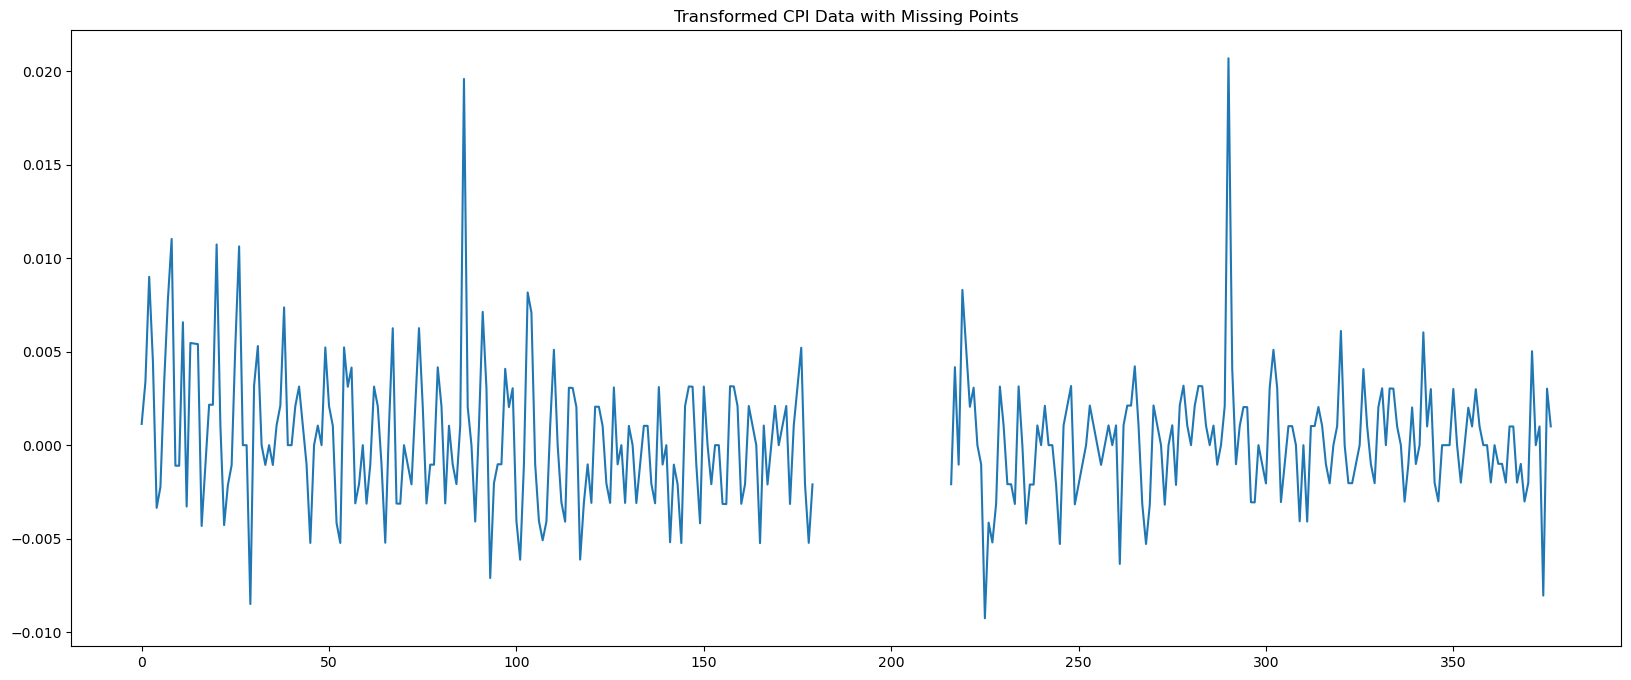

In [60]:
plt.figure(figsize = (20,8))
plt.plot(y_missing)
plt.title("Transformed CPI Data with Missing Points")
plt.show()

The Kalman filter is the same as before, but now when we have no observation $y_t$, we can't update our prior belief, so we skip the update entirely and carry the prediction forward unchanged: $s_{t|t} = s_{t|t-1}$ and $\Sigma_{t|t} = \Sigma_{t|t-1}$ (In the stored arrays this corresponds to a zero innovation $v_t$, zero Kalman gain $K_t$, and undefined innovation variance $V_t$, since no innovation is formed).

In [61]:
def kalman_filter_full(sigma_squared_eta, T, Z, R, y):
    m = T.shape[0]  # state dimension
    n = len(y)      # num time steps

    # storage
    v_all = np.zeros(n) # innovations
    V_all = np.zeros(n) # innovation variances
    K_all = np.zeros((n, m, 1)) # Kalman gains
    s_filt_all   = np.zeros((n, m)) # filtered states s_{t|t}
    sig_filt_all = np.zeros((n, m, m)) # filtered covariances Sigma_{t|t}
    s_pred_all   = np.zeros((n, m)) # predicted states s_{t|t-1}
    sig_pred_all = np.zeros((n, m, m)) # predicted covariances Sigma_{t|t-1}

    # diffuse initialization
    s_pred = np.zeros((m, 1))
    sig_pred = np.eye(m) * 1e6

    y = y.values if hasattr(y, 'values') else np.asarray(y) # to numpy if pandas

    for t in range(n):
        # store predicted
        s_pred_all[t]   = s_pred.flatten()
        sig_pred_all[t] = sig_pred

        if np.isnan(y[t]):
            # missing observation: skip the update, carry the prediction forward
            s_filt = s_pred
            sig_filt = sig_pred
            v_all[t] = 0.0       # no innovation
            V_all[t] = np.nan    # undefined
            K_all[t] = 0.0       # no gain
        else:
            # 1. innovation
            v = float((y[t] - Z @ s_pred).squeeze())
            
            # 2. innovation variance
            V = float((Z @ sig_pred @ Z.T).squeeze())
            
            v_all[t] = v
            V_all[t] = V
            
            # 3. Kalman gain
            C = sig_pred @ Z.T
            K = T @ C / V
            K_all[t] = K
            
            # 4. update state estimate
            s_filt = s_pred + (C / V) * v
            
            # 5. update state uncertainty
            sig_filt = sig_pred - (C/V) * C.T

        # store filtered
        s_filt_all[t]   = s_filt.flatten()
        sig_filt_all[t] = sig_filt

        # 6. predict state at next step
        s_pred = T @ s_filt
        
        # 7. predict state uncertainty at next step
        sig_pred = T @ sig_filt @ T.T + sigma_squared_eta * R @ R.T

    return v_all, V_all, K_all, s_filt_all, sig_filt_all, s_pred_all, sig_pred_all

In [62]:
v_all_missing, V_all_missing, K_all_missing, s_filt_all_missing, sig_filt_all_missing, s_pred_all_missing, sig_pred_all_missing = kalman_filter_full(sigma_squared_eta, T, Z, R, y_missing)

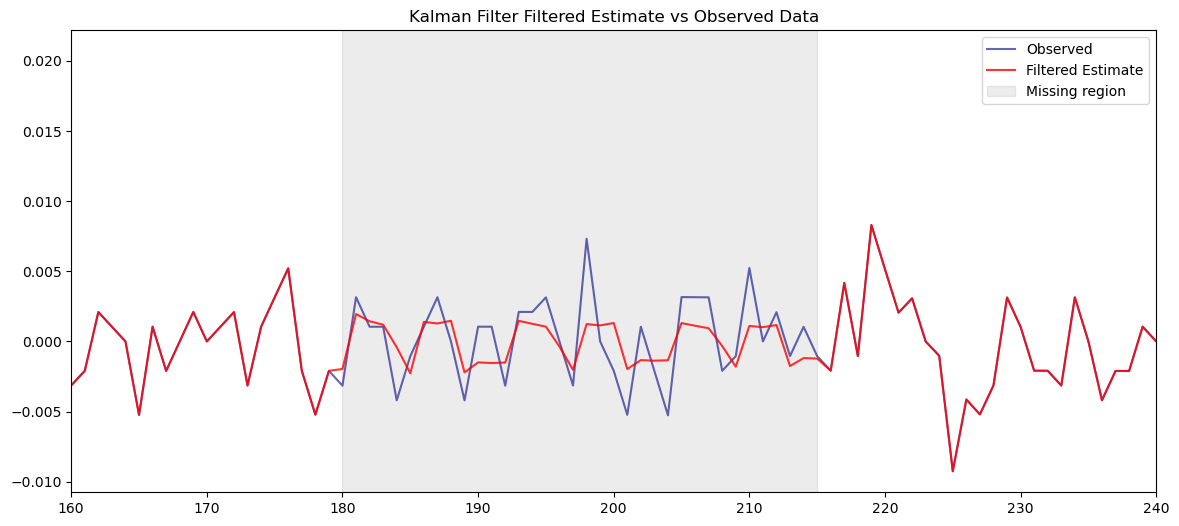

In [63]:
plt.figure(figsize=(14, 6))
plt.plot(y.values, color='navy', label='Observed', alpha=0.6)
plt.plot(s_filt_all_missing[:, 0], color='red', label='Filtered Estimate', alpha=0.8)

plt.xlim(160, 240) # zoom around the gap (180–216)
plt.title('Kalman Filter Filtered Estimate vs Observed Data')
plt.axvspan(180, 215, color='gray', alpha=0.15, label='Missing region')
plt.legend()

plt.show()

In the gap, the filter has no observations to update on, so its estimate reflects only the model's dynamics propagated forward from the last observed point. It decays toward the series mean as the gap widens. This is the best a filter can do, since it only sees the past.

When we run the smoother, we can expect to see better interpolations through the gap, since the smoother uses both past and future observations,  unlike the filter, which only has data up to each point.


### Kalman Smoother

The Kalman Smoother Algorithm is: 

Initialize $q_t = 0$, $M_t = 0$ Running backwards from t = T to t = 1:


$$ \text{define } L_t = (T_t - K_tZ_t)$$

$$ q_{t-1} = Z_t' V_t^{-1} v_t + L_t' q_t\tag{weighted sum of future innovations}$$ 


$$s_{t|T} = s_{t|t-1} + \Sigma_{t|t-1} q_{t-1} \tag{calculate smoothed state estimate}$$ 


$$M_{t-1} = Z_t' V_t^{-1} Z_t + L_t' M_t L_t \tag{wgt. sum of precision of future inov.}$$ 

$$\Sigma_{t|T} = \Sigma_{t|t-1} - \Sigma_{t|t-1} M_{t-1} \Sigma_{t|t-1} \tag{calculate smoothed variance}$$ 


When data is missing, however, $v_t$ is undefined and $V_t$ is NaN, so our weighted sum steps simply become 

$$q_{t-1} = L_t' q_t$$

$$M_{t-1} = L_t' M_t L_t$$ 

And $K = 0$ so 
$$L_t = T_t$$






In [64]:
def kalman_smoother(T, Z, v_all, V_all, K_all, s_pred_all, sig_pred_all):
    n = s_pred_all.shape[0]
    m = T.shape[0]

    # storage
    s_smooth_all   = np.zeros((n, m)) # smoothed states s_{t|T}
    sig_smooth_all = np.zeros((n, m, m)) # smoothed covariances Sigma_{t|T}

    # initialize backward recursion at the terminal time
    q = np.zeros((m, 1))   # q_T = 0
    M = np.zeros((m, m))   # M_T = 0

    # run backwards from t = n-1 to t = 0
    for t in reversed(range(n)):
        if np.isnan(V_all[t]):
            # missing observation: no innovation term, L_t = T (since K_t = 0)
            L = T
            q = L.T @ q
            M = L.T @ M @ L
        
        else:
            # normal step
            L = T - K_all[t] @ Z
            q = Z.T * (v_all[t] / V_all[t]) + L.T @ q
            M = Z.T @ Z / V_all[t] + L.T @ M @ L

        # smoothed state and covariance
        s_smooth_all[t]   = (s_pred_all[t].reshape(-1, 1) + sig_pred_all[t] @ q).flatten()
        sig_smooth_all[t] = sig_pred_all[t] - sig_pred_all[t] @ M @ sig_pred_all[t]

    return s_smooth_all, sig_smooth_all


In [65]:
s_smooth_all_missing, sig_smooth_all_missing = kalman_smoother(T, Z, v_all_missing, V_all_missing, K_all_missing, s_pred_all_missing, sig_pred_all_missing)


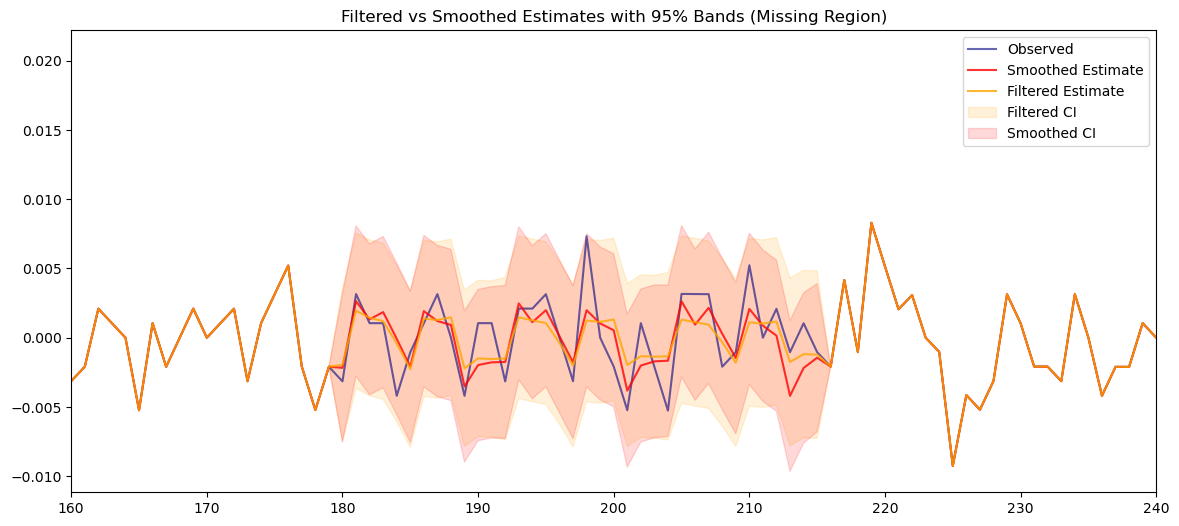

In [66]:
plt.figure(figsize=(14, 6))
plt.plot(y.values, color='navy', label='Observed', alpha=0.6)
plt.plot(s_smooth_all_missing[:, 0], color='red', label='Smoothed Estimate', alpha=0.8)
plt.plot(s_filt_all_missing[:, 0], color='orange', label='Filtered Estimate', alpha=0.8)

# standard errors (clip tiny negatives from floating point before sqrt)
filt_se   = np.sqrt(np.maximum(sig_filt_all_missing[:, 0, 0], 0))
smooth_se = np.sqrt(np.maximum(sig_smooth_all_missing[:, 0, 0], 0))

plt.fill_between(range(len(y)),
                 s_filt_all_missing[:, 0] - 1.96*filt_se,
                 s_filt_all_missing[:, 0] + 1.96*filt_se,
                 color='orange', alpha=0.15, label = 'Filtered CI')
plt.fill_between(range(len(y)),
                 s_smooth_all_missing[:, 0] - 1.96*smooth_se,
                 s_smooth_all_missing[:, 0] + 1.96*smooth_se,
                 color='red', alpha=0.15, label = 'Smoothed CI')

plt.xlim(160, 240)
plt.title('Filtered vs Smoothed Estimates with 95% Bands (Missing Region)')
plt.legend()
plt.show()

Looking at our gap, it's hard to tell whether the smoothed estimates are better than the filtered estimates; they are both very close. The smoothed CI band (red), however, is visibly tighter than the filtered CI band (yellow). This is the smoother's advantage: the filter only uses observations up to each point, while the smoother incorporates data from both sides of the gap, so uncertainty about the missing values is reduced. 

In this case, both bands stay relatively contained rather than ballooning, because the strong seasonal component still supplies information about each missing month from adjacent years.

# Recap
In this exercise we:

1. Looked at raw CPI data and applied transformations to achieve stationarity (passing ADF/KPSS tests)
3. Performed model selection on the transformed series with grid search and picked the model(s) with the lowest AIC/BIC
4. Confirmed the best model via visual checks (diagnostic plots) and formal tests (normality/heteroskedasticity/ARCH effects)
5. Expanded our selected $ARMA(1,3)\times(1,1)_{12}$ to $ARMA(13,15)$, and converted to $ARMA(m, m-1)$ to use Harvey's method
6. Applied Harvey's method to convert our ARMA model to a state-space representation, defining matrices T, Z, R, Q, and H
7. Demonstrated Prediction Error Decomposition of the Likelihood, running the Kalman Filter iteratively to numerically estimate $\sigma^2_\eta$, and confirmed it matches the ARIMA innovation variance, as expected under Harvey's single-shock form
8. With all state-space matrices defined and parameters estimated, ran the Kalman Filter on our transformed series, storing $v_t$, $V_t$, $K_t$, $s_{t|t}$, $s_{t+1|t}$ for each time step
9. Showed that the Kalman filter on the state-space representation replicates the fitted ARMA — its one-step-ahead predictions leave white-noise residuals, and its 10-step-ahead forecasts and confidence bands match `statsmodels` exactly
10. Ran the Kalman filter and smoother on the transformed data with missing values to demonstrate missing-value handling, a major benefit of state-space representations, with the smoother giving tighter interpolation bands than the filter